# 6G Smart City IDS — Unified Notebook (mMTC / URLLC / eMBB / TON_IoT)

## 📌 Library Imports
### 1. Import Required Libraries

Imports all necessary Python libraries:
- **pandas / numpy** → Data manipulation and numerical computation
- **matplotlib / seaborn** → Data visualization
- **sklearn modules** → Preprocessing, modeling, and evaluation
- **imblearn** → SMOTE for class imbalance handling (TON_IoT)


## 🔍 Cell Description — Library Imports

This cell imports **all Python dependencies** required throughout the entire notebook. Here is what each import group provides:

| Import | Purpose |
|---|---|
| `os`, `pathlib.Path` | File system operations — checking if dataset files exist before loading |
| `numpy`, `pandas` | Core data manipulation: arrays, DataFrames, column operations |
| `matplotlib`, `seaborn` | Visualization: bar charts, histograms, heatmaps, ROC curves |
| `sklearn.compose.ColumnTransformer` | Apply different preprocessing pipelines to numeric vs categorical columns simultaneously |
| `sklearn.ensemble.RandomForestClassifier` | Primary model — ensemble of decision trees using bagging |
| `sklearn.ensemble.GradientBoostingClassifier` | Fallback boosting model if XGBoost is not installed |
| `sklearn.impute.SimpleImputer` | Fill missing values (NaN) using median or most-frequent strategies |
| `sklearn.linear_model.LogisticRegression` | Baseline linear classifier for benchmark comparison |
| `sklearn.metrics.*` | Evaluation tools: accuracy, F1, AUC-ROC, confusion matrix, classification report |
| `sklearn.model_selection.train_test_split` | Split data into 75% train / 25% test with stratified sampling |
| `sklearn.pipeline.Pipeline` | Chain imputer → transformer → scaler into a single reusable object |
| `sklearn.preprocessing.*` | `FunctionTransformer` (log1p), `LabelEncoder` (string→int), `OneHotEncoder`, `RobustScaler`, `StandardScaler` |
| `imblearn.over_sampling.SMOTE` | Synthetic Minority Oversampling — generates synthetic attack samples to balance skewed datasets |
| `xgboost.XGBClassifier` | Advanced gradient boosted trees; falls back to `GradientBoostingClassifier` if unavailable |
| `warnings` | Suppresses non-critical sklearn/numpy deprecation warnings for cleaner output |

The `try/except` block around XGBoost sets a flag `USE_XGBOOST = True/False` so the rest of the notebook can branch between XGBoost and the sklearn fallback without crashing.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score,
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, RocCurveDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer, LabelEncoder,
    OneHotEncoder, RobustScaler, StandardScaler
)
from imblearn.over_sampling import SMOTE

try:
    from xgboost import XGBClassifier
    USE_XGBOOST = True
    print('XGBoost available')
except ImportError:
    USE_XGBOOST = False
    print('XGBoost not found, using GradientBoosting')
import warnings
warnings.filterwarnings('ignore')
print('All imports successful')


XGBoost available
All imports successful


## 📌 Dataset Loading
### 2. Dataset Loading

Loads the four datasets:
- **mMTC** — Massive Machine Type Communications
- **URLLC** — Ultra-Reliable Low Latency Communications
- **eMBB** — Enhanced Mobile Broadband
- **TON_IoT** — Real-world IoT network traffic benchmark (replaces G6)


## 🔍 Cell Description — Google Drive Mount

This cell mounts Google Drive into the Colab runtime at `/content/drive`. This is **required before loading any dataset** because all four CSV files are stored in a Google Drive folder (`MyDrive/data5g/`). Once mounted, Colab can read files from Drive just like a local path. This step is specific to Google Colab — in a local Jupyter environment you would skip this and adjust the file paths in Cell 5 directly.

## 🔍 Cell Description — Dataset Loading Function

This cell defines `load_dataset()` and calls it four times to load all datasets into a shared `datasets` dictionary.

**How `load_dataset()` works:**
1. **Checks file existence** with `os.path.exists()` — if the file is missing it prints a warning and returns `None` (safe failure).
2. **Reads the CSV** using the correct separator — semicolon (`;`) for TON_IoT, comma (`,`) for the three 6G slice datasets (mMTC, URLLC, eMBB).
3. **TON_IoT-specific cleaning:**
   - Drops unnamed index columns (`Unnamed:...`) that pandas sometimes adds when saving CSVs.
   - Strips whitespace from all column names.
   - Renames the original `Label` column to `label_raw` (preserving the raw 0/1 integer).
   - Drops rows where `label_raw` is NaN or non-numeric (data quality guard).
   - Casts `label_raw` to float → int to avoid type errors.
   - Creates a new human-readable `Label` column: `0 → 'Benign'`, `1 → 'Malicious'`.
4. **Standard datasets:** only strips whitespace from column names.
5. After loading, any dataset that failed to load (`None`) is filtered out of the `datasets` dict, so all downstream code only sees valid DataFrames.

**Datasets loaded:**

| Key | File | 6G Slice |
|---|---|---|
| `mMTC` | `mMTC.csv` | Massive Machine Type Communications |
| `URLLC` | `URLLC.csv` | Ultra-Reliable Low Latency Communications |
| `eMBB` | `eMBB.csv` | Enhanced Mobile Broadband |
| `TON_IoT` | `train_test_network.csv` | Real-world IoT benchmark (9 attack types) |

In [2]:
def load_dataset(name, filename):
    if os.path.exists(filename):
        # Auto-detect separator: try semicolon first, fallback to comma
        with open(filename, 'r', encoding='utf-8', errors='replace') as _f:
            first_line = _f.readline()
        sep = ';' if first_line.count(';') > first_line.count(',') else ','
        print(f'{name}: detected separator={repr(sep)}')
        df  = pd.read_csv(filename, sep=sep, low_memory=False)
        if name == 'TON_IoT':
            df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
            df.columns = df.columns.str.strip()
            if 'Label' in df.columns:
                df = df.rename(columns={'Label': 'label_raw'})

            # Drop rows where label_raw is NaN or infinite before casting
            df = df[pd.to_numeric(df['label_raw'], errors='coerce').notna()]
            df['label_raw'] = df['label_raw'].astype(float)  # float first, then int

            df['Label'] = df['label_raw'].astype(int).map({0: 'Benign', 1: 'Malicious'})
        else:
            df.columns = df.columns.str.strip()
        print(f'Loaded {name}: {df.shape}')
        return df
    else:
        print(f'Skipped {name}: file not found ({filename})')
        return None

datasets = {}
datasets['mMTC']    = load_dataset('mMTC',    'Data5G/mMTC.csv')
datasets['URLLC']   = load_dataset('URLLC',   'Data5G/URLLC.csv')
datasets['eMBB']    = load_dataset('eMBB',    'Data5G/eMBB.csv')
datasets['TON_IoT'] = load_dataset('TON_IoT', 'Data5G/train_test_network.csv')
datasets = {k: v for k, v in datasets.items() if v is not None}
print(f'\nLoaded {len(datasets)} datasets:', list(datasets.keys()))


mMTC: detected separator=','
Loaded mMTC: (4615, 52)
URLLC: detected separator=','
Loaded URLLC: (4033, 52)
eMBB: detected separator=','
Loaded eMBB: (5808, 52)
TON_IoT: detected separator=','
Loaded TON_IoT: (210969, 45)

Loaded 4 datasets: ['mMTC', 'URLLC', 'eMBB', 'TON_IoT']


## 📌 Basic Dataset Overview
### 3. Dataset Overview
Structural summary of each dataset: shape, label distribution, data types.


## 🔍 Cell Description — Dataset Overview Function

This cell defines `dataset_overview()` and runs it on every loaded dataset to produce a quick structural summary.

**What it computes and displays per dataset:**
- **Shape** — number of rows and columns (e.g., `(50000, 15)`)
- **Dtypes** — count of numeric vs object columns (helps spot unexpected string columns)
- **Label distribution** — how many Benign vs Malicious samples exist
- **Imbalance ratio** — `max_class_count / min_class_count`; a ratio above 2.0 triggers SMOTE later
- **Two side-by-side horizontal bar charts:**
  - Left: label counts (green = Benign, red = Malicious)
  - Right: data type breakdown (blue)

**Why this matters:** Understanding imbalance early is critical. If 95% of samples are Benign and only 5% Malicious, a naive model can achieve 95% accuracy by always predicting Benign — but it would be useless as an IDS. This overview sets the expectation for where SMOTE will be needed.


=== mMTC ===
  Shape  : (4615, 52)
  Dtypes : {dtype('float64'): 38, dtype('O'): 7, dtype('int64'): 7}
  Labels : {'Benign': 2462, 'Malicious': 2153}
  Imbalance ratio: 1.14:1


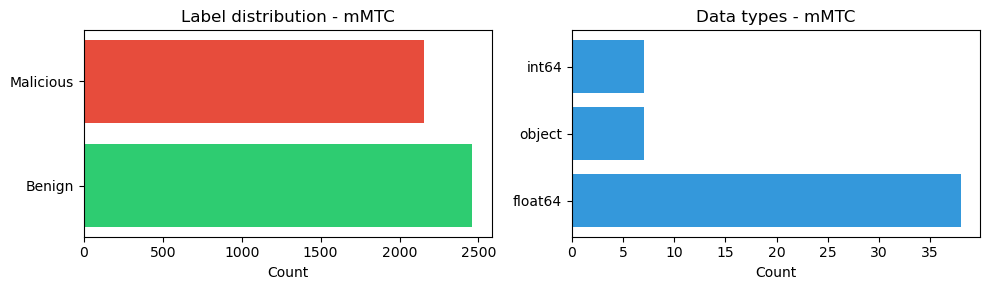


=== URLLC ===
  Shape  : (4033, 52)
  Dtypes : {dtype('float64'): 32, dtype('int64'): 13, dtype('O'): 7}
  Labels : {'Malicious': 2461, 'Benign': 1572}
  Imbalance ratio: 1.57:1


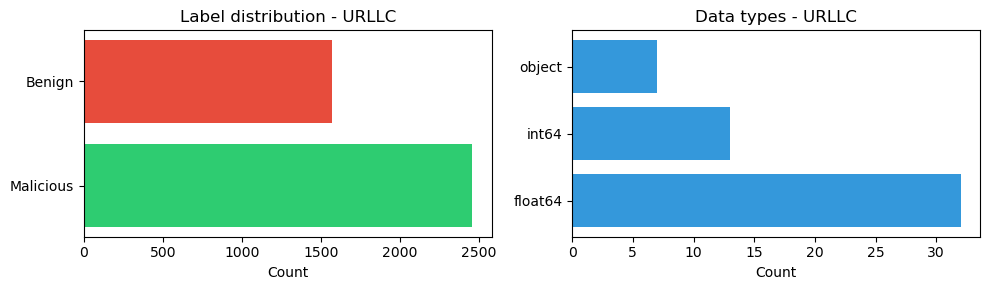


=== eMBB ===
  Shape  : (5808, 52)
  Dtypes : {dtype('float64'): 33, dtype('int64'): 12, dtype('O'): 7}
  Labels : {'Benign': 3023, 'Malicious': 2785}
  Imbalance ratio: 1.09:1


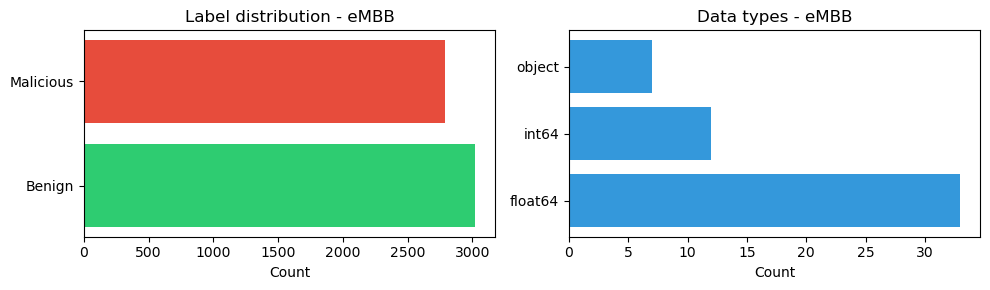


=== TON_IoT ===
  Shape  : (210969, 45)
  Dtypes : {dtype('O'): 28, dtype('float64'): 15, dtype('int64'): 2}
  Labels : {'Malicious': 160986, 'Benign': 49983}
  Imbalance ratio: 3.22:1


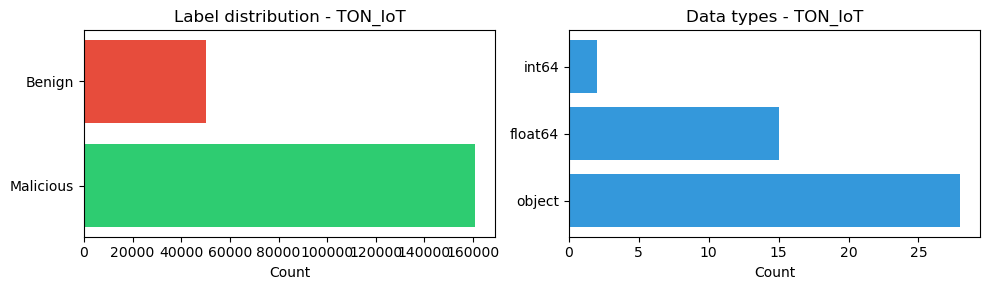

In [3]:
def dataset_overview(df, name, label_col='Label'):
    print(f'\n=== {name} ===')
    if label_col not in df.columns:
        print(f'  Warning: label column not found. Columns: {list(df.columns)}')
        return
    print(f'  Shape  : {df.shape}')
    print(f'  Dtypes : {dict(df.dtypes.value_counts())}')
    vc = df[label_col].value_counts(dropna=False)
    print(f'  Labels : {dict(vc)}')
    ratio = vc.max() / vc.min()
    print(f'  Imbalance ratio: {ratio:.2f}:1')

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].barh(vc.index.astype(str), vc.values, color=['#2ecc71','#e74c3c'])
    axes[0].set_title(f'Label distribution - {name}')
    axes[0].set_xlabel('Count')
    dtype_counts = df.dtypes.value_counts()
    axes[1].barh(dtype_counts.index.astype(str), dtype_counts.values, color='#3498db')
    axes[1].set_title(f'Data types - {name}')
    axes[1].set_xlabel('Count')
    plt.tight_layout()
    plt.show()

for n, d in datasets.items():
    dataset_overview(d, n)


## 📌 Data Quality Report
### 4. Data Quality Assessment
Evaluates: missing values, duplicate rows, outlier percentage.


## 🔍 Cell Description — Data Quality Assessment

This cell defines `quality_report_graph()` and evaluates three data quality metrics for each dataset, displayed as a bar chart.

**Metric 1 — Missing values %:**
- Counts all NaN cells across the entire DataFrame.
- Formula: `(total NaN cells) / (rows × columns) × 100`
- High missing % would require imputation strategy decisions.

**Metric 2 — Duplicate rows %:**
- Counts rows that are exact duplicates of a prior row.
- Formula: `duplicate_count / total_rows × 100`
- High duplicates would inflate model performance artificially.

**Metric 3 — Outlier %:**
- Uses the **IQR method** for every numeric column:
  - Compute Q1 (25th percentile) and Q3 (75th percentile)
  - IQR = Q3 − Q1
  - Any value below `Q1 − 1.5×IQR` or above `Q3 + 1.5×IQR` is flagged as an outlier
- Formula: `total outlier cells / (rows × numeric_columns) × 100`
- High outlier % motivates using `RobustScaler` (which is median-based and less sensitive to extremes) rather than `StandardScaler` in the preprocessing pipeline.

**Visual output:** A color-coded bar chart per dataset (red = missing, blue = duplicates, orange = outliers).

mMTC — Missing: 5.58% | Duplicates: 0.00% | Outliers: 8.88%


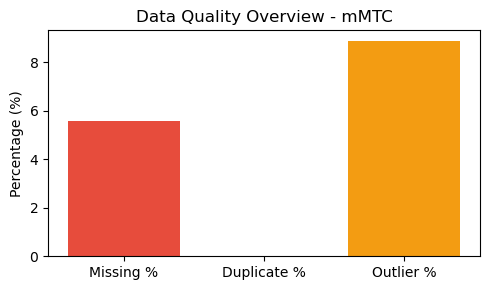

URLLC — Missing: 17.38% | Duplicates: 0.00% | Outliers: 6.77%


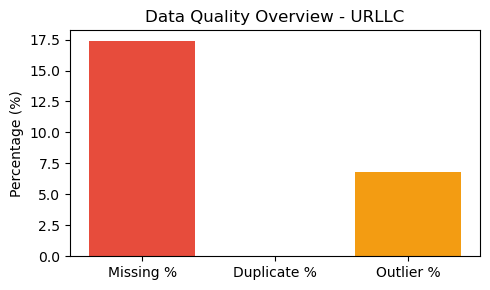

eMBB — Missing: 3.85% | Duplicates: 0.00% | Outliers: 4.62%


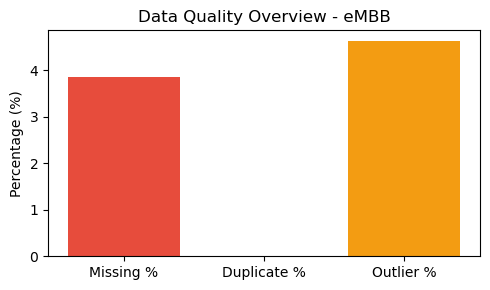

TON_IoT — Missing: 0.00% | Duplicates: 9.75% | Outliers: 11.69%


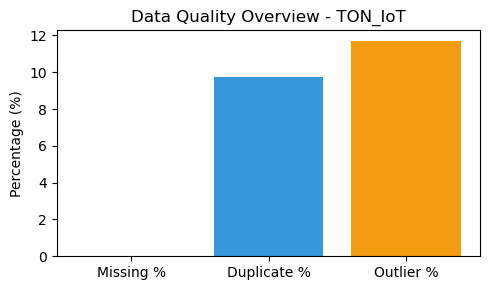

In [4]:
def quality_report_graph(df, name):
    total_rows = len(df)
    missing_pct   = (df.isna().sum().sum() / (df.shape[0] * df.shape[1])) * 100
    duplicate_pct = (df.duplicated().sum() / total_rows) * 100
    num_cols = df.select_dtypes(include=np.number).columns
    outlier_total = 0
    for col in num_cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        outlier_total += ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_pct = (outlier_total / (total_rows * max(len(num_cols),1))) * 100
    print(f'{name} — Missing: {missing_pct:.2f}% | Duplicates: {duplicate_pct:.2f}% | Outliers: {outlier_pct:.2f}%')
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(['Missing %','Duplicate %','Outlier %'],
           [missing_pct, duplicate_pct, outlier_pct],
           color=['#e74c3c','#3498db','#f39c12'])
    ax.set_title(f'Data Quality Overview - {name}')
    ax.set_ylabel('Percentage (%)')
    plt.tight_layout()
    plt.show()

for n, d in datasets.items():
    quality_report_graph(d, n)


## 📌 Exploratory Data Analysis (EDA)
### 5.1 Class Distribution


## 🔍 Cell Description — EDA: Class Distribution Bar Charts

This cell defines `plot_class_distribution()` and calls it once per dataset. It plots a **simple vertical bar chart** showing the raw count of each class label (`Benign` vs `Malicious`).

**Why this is different from Cell 7's overview:** Cell 7 shows the imbalance ratio as a number. This cell makes it *visually obvious* — a very tall green bar next to a short red bar immediately communicates that the dataset is heavily skewed toward Benign traffic, which is realistic in network data.

**Design choice:** Green (`#2ecc71`) for Benign, red (`#e74c3c`) for Malicious — consistent color coding used throughout the notebook.

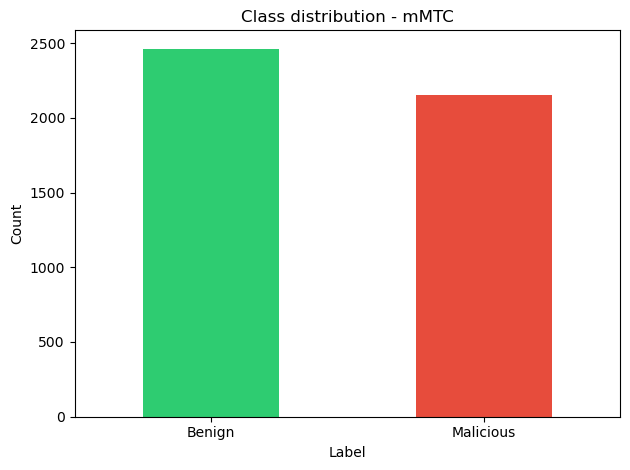

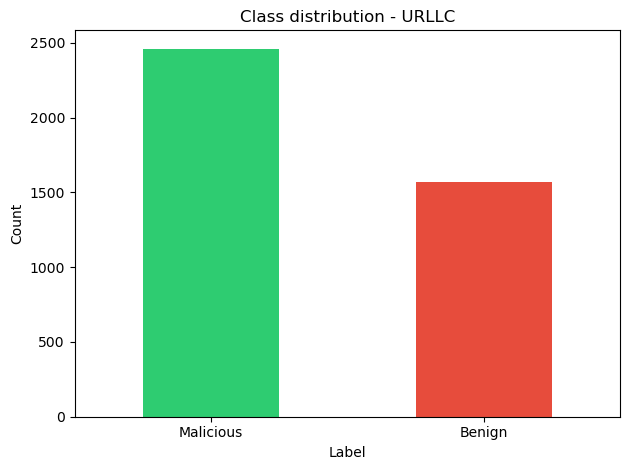

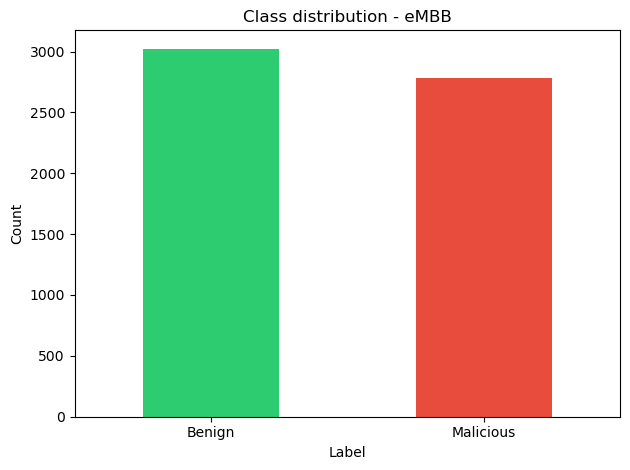

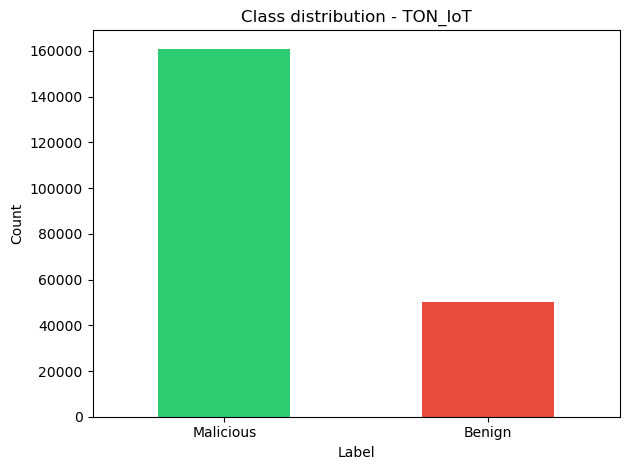

In [5]:
def plot_class_distribution(df, name, label_col='Label'):
    if label_col not in df.columns:
        print(f'Column not found in {name}')
        return
    vc = df[label_col].value_counts()
    ax = vc.plot(kind='bar', color=['#2ecc71','#e74c3c'])
    ax.set_title(f'Class distribution - {name}')
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

for n, d in datasets.items():
    plot_class_distribution(d, n)


## 5.2 Attack Type Breakdown
Shows attack subtypes per dataset. Used for understanding only — `type` column is excluded from features.


## 🔍 Cell Description — EDA: Attack Type Breakdown (Subtypes)

This cell maps each dataset to its attack subtype column (`type`) and plots a breakdown of attack categories within malicious traffic.

**Key design decision — `TYPE_COL` dictionary:**
- `mMTC`, `URLLC`, `eMBB` → `None` — these 6G slice datasets only have a binary `Label` column; no attack subtype information is available.
- `TON_IoT` → `'type'` — this dataset includes a `type` column with 9 named attack categories (e.g., DDoS, Ransomware, Backdoor, Scanning, etc.).

**Important note:** The `type` column is intentionally **excluded from model features** (it is dropped in `make_xy()` in Cell 19). It is used here for *understanding only* — to know what kinds of attacks we are dealing with. Using it as a feature would be data leakage (the model would be predicting attack type using attack type).

**Output:** For TON_IoT, a rotated bar chart shows each of the 9 attack subtypes and their frequency. For the other three datasets, a message confirms no subtype column exists.

mMTC — no attack subtype column (binary label only)
URLLC — no attack subtype column (binary label only)
eMBB — no attack subtype column (binary label only)

TON_IoT — Attack type breakdown:
type
normal        49983
dos           20000
ransomware    20000
scanning      20000
injection     19998
xss           19995
ddos          19986
backdoor      19982
password      19982
mitm           1043


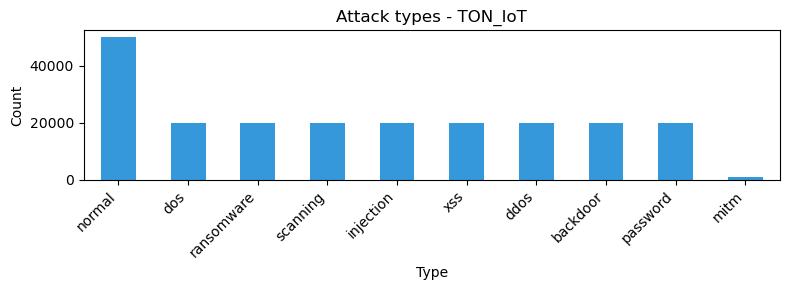

In [6]:
# Attack subtype column varies per dataset
TYPE_COL = {
    'mMTC':    None,  # no subtype column in slice datasets
    'URLLC':   None,
    'eMBB':    None,
    'TON_IoT': 'type',
}

for n, d in datasets.items():
    col = TYPE_COL.get(n)
    if col and col in d.columns:
        print(f'\n{n} — Attack type breakdown:')
        tc = d[col].value_counts()
        print(tc.to_string())
        fig, ax = plt.subplots(figsize=(8, 3))
        tc.plot(kind='bar', ax=ax, color='#3498db')
        ax.set_title(f'Attack types - {n}')
        ax.set_xlabel('Type')
        ax.set_ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print(f'{n} — no attack subtype column (binary label only)')


## 5.3 Numeric Feature Distribution Analysis


## 🔍 Cell Description — EDA: Numeric Feature Histograms

This cell defines `plot_numeric_hists()` and generates **histogram grids** for the first 8 numeric features of each dataset.

**What it does:**
- Selects all numeric columns (float64, int64), excluding `UniqueID`, `X`, and `label_raw` (index/metadata columns with no predictive value).
- Limits to 8 columns maximum to keep the plot readable.
- Plots a 30-bin histogram grid using pandas' `.hist()`.

**Why histograms matter here:** Network traffic features are typically **heavily right-skewed** — most connections are short and low-volume, but a few are extremely large (DDoS attacks, large file transfers). Seeing this skew visually justifies the `log1p` transformation applied in the preprocessing pipeline (Cell 19), which compresses large values and makes the distribution more symmetric for ML models.

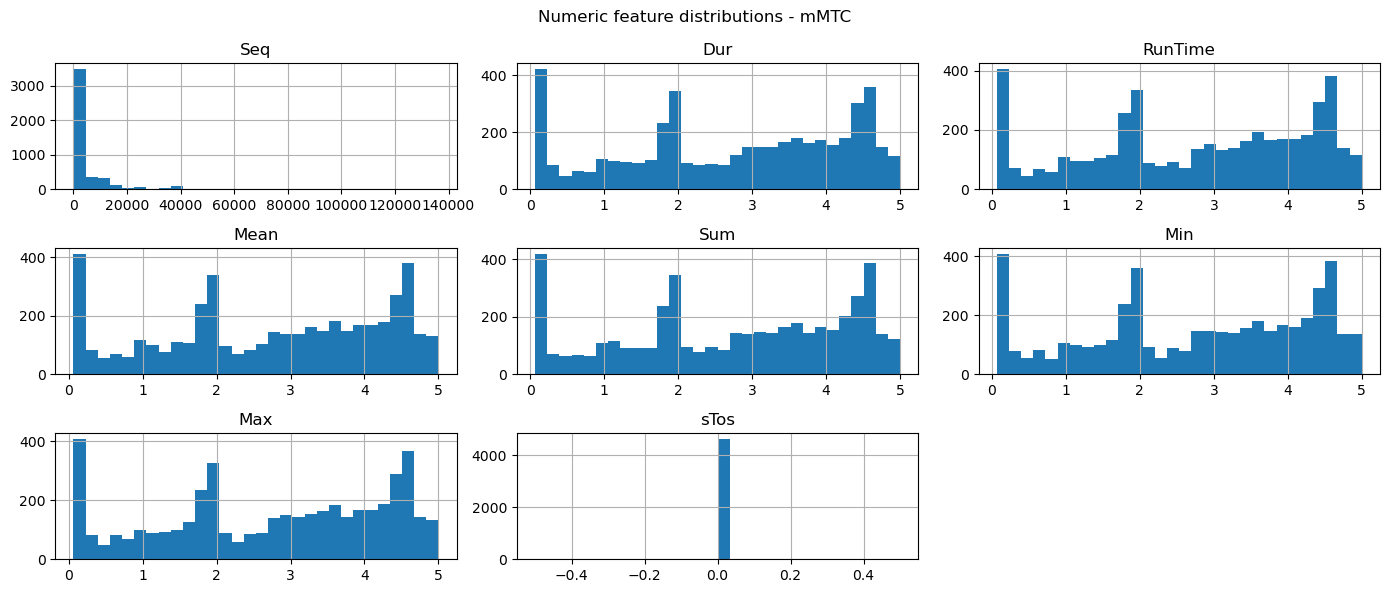

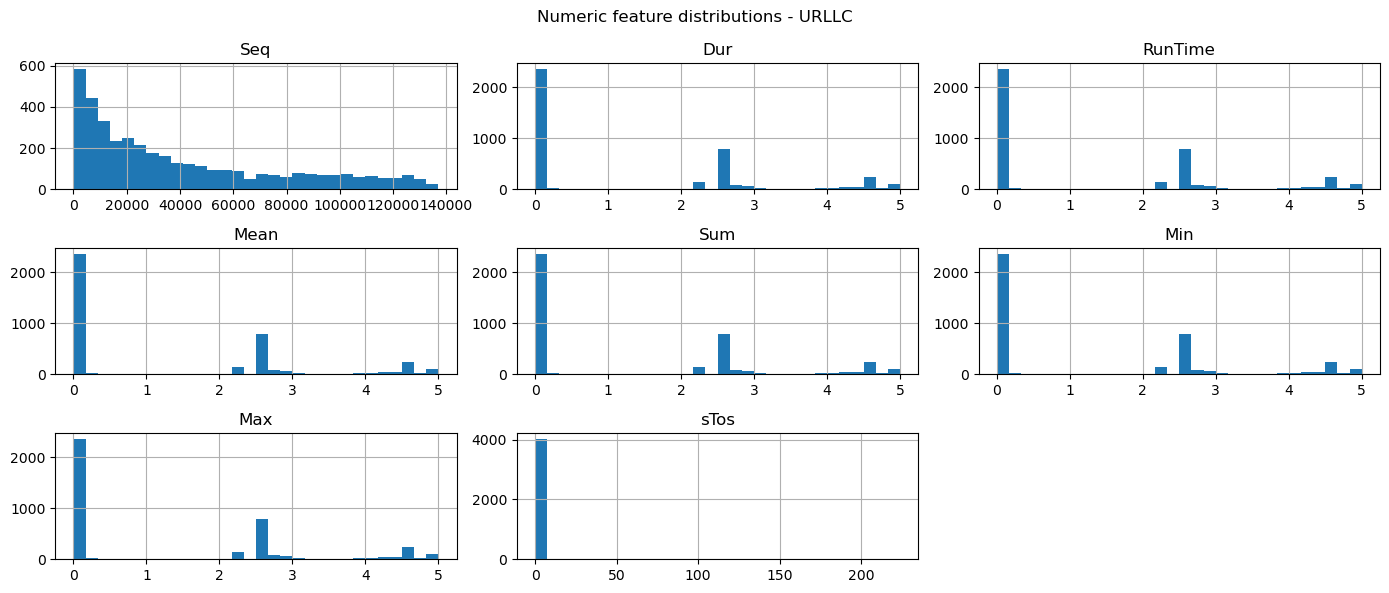

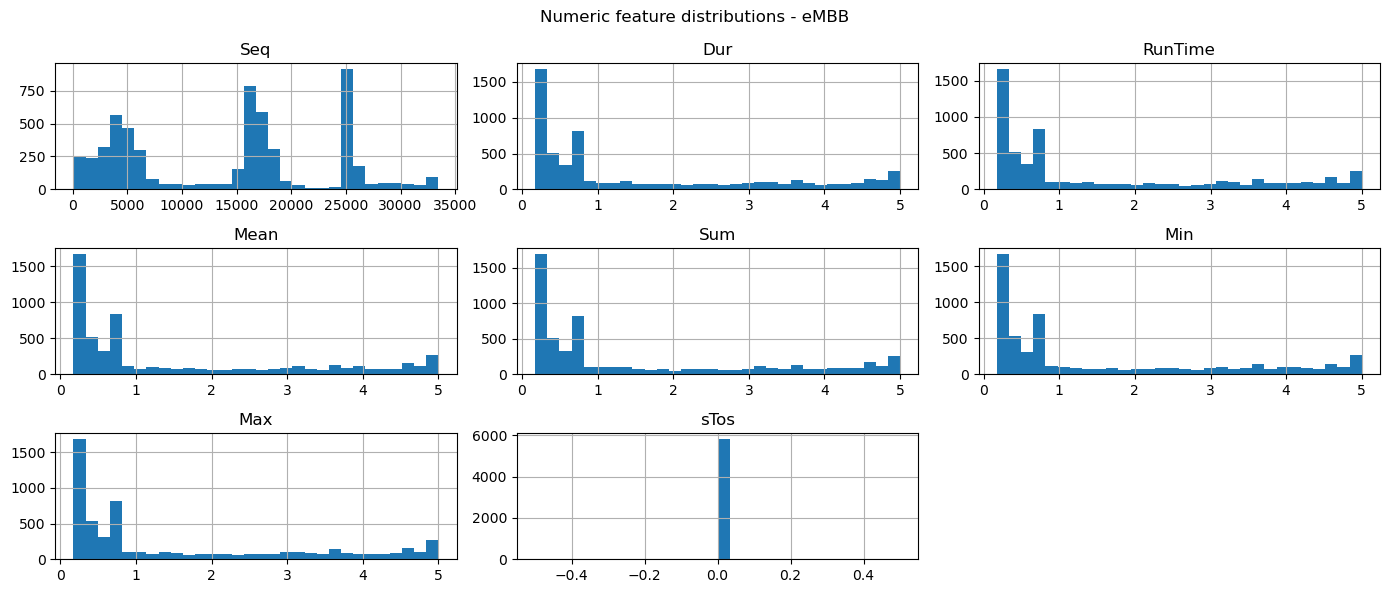

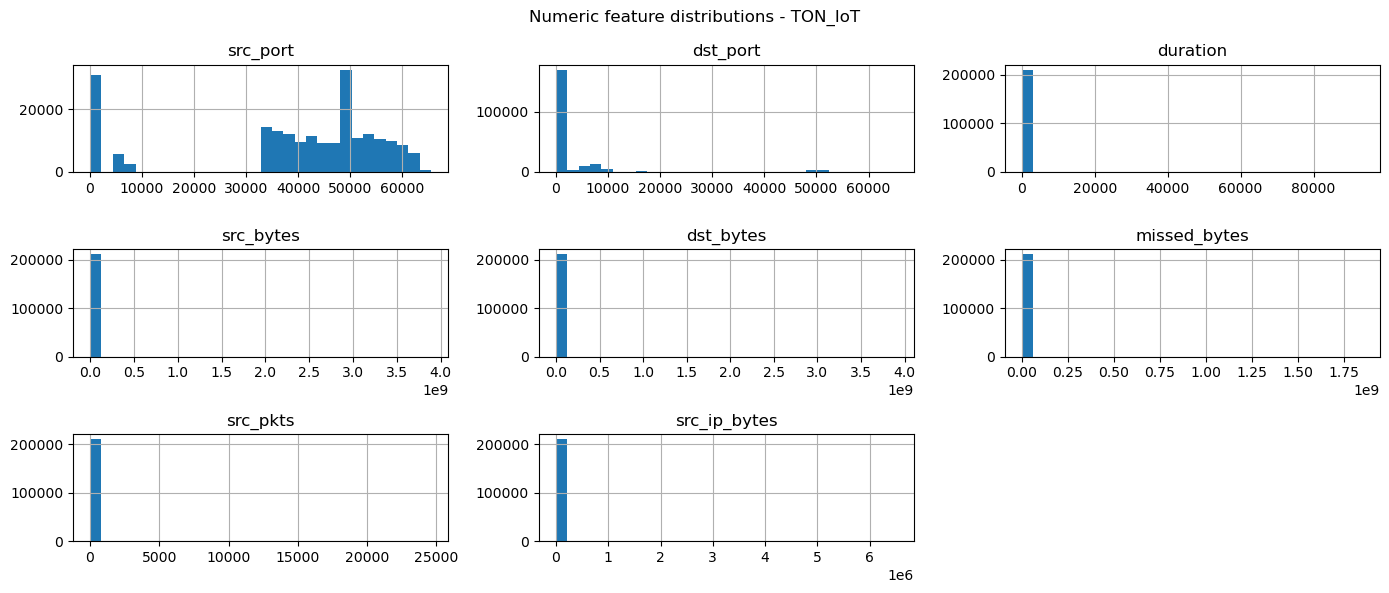

In [7]:
def plot_numeric_hists(df, name, n_cols=8):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    exclude  = ['UniqueID','X','label_raw']
    num_cols = [c for c in num_cols if c not in exclude][:n_cols]
    if not num_cols:
        print(f'No numeric columns for {name}')
        return
    df[num_cols].hist(bins=30, figsize=(14, 6))
    plt.suptitle(f'Numeric feature distributions - {name}')
    plt.tight_layout()
    plt.show()

for n, d in datasets.items():
    plot_numeric_hists(d, n)


## 5.4 Correlation Analysis


## 🔍 Cell Description — EDA: Correlation Matrix Heatmap

This cell defines `plot_correlation_matrix()` and plots a **Pearson correlation heatmap** for all numeric features in each dataset.

**What it does:**
- Selects all numeric columns, excluding metadata columns (`UniqueID`, `X`, `label_raw`).
- Computes pairwise Pearson correlation coefficients (values range from −1 to +1).
- Displays as a `seaborn` heatmap with a `coolwarm` colormap (blue = negative correlation, red = positive, white = near zero).

**How to read the heatmap:**
- **Dark red cells** (correlation ≈ +1): two features are nearly redundant (e.g., `TotBytes` and `Load` often correlate strongly in network data).
- **Dark blue cells** (correlation ≈ −1): features move in opposite directions.
- **White/neutral cells**: features are independent — both are informative.

**Why this matters:** Highly correlated features add redundancy. The feature selection in Cells 21–24 was partly guided by these correlations — choosing a subset that retains variety rather than repeating the same signal in multiple columns.

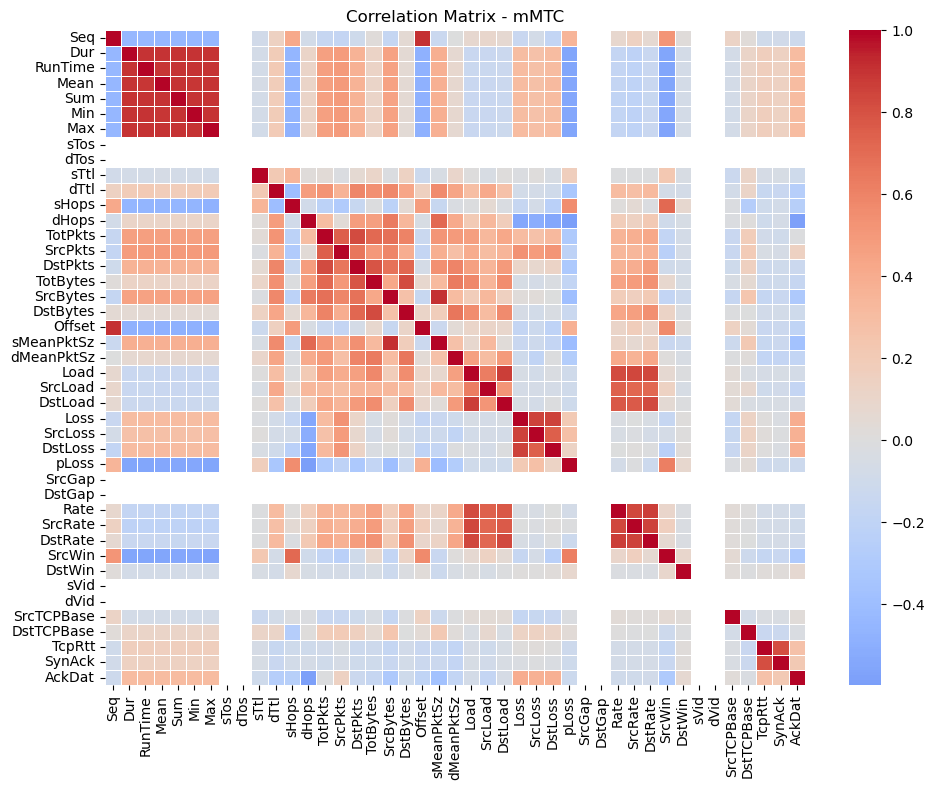

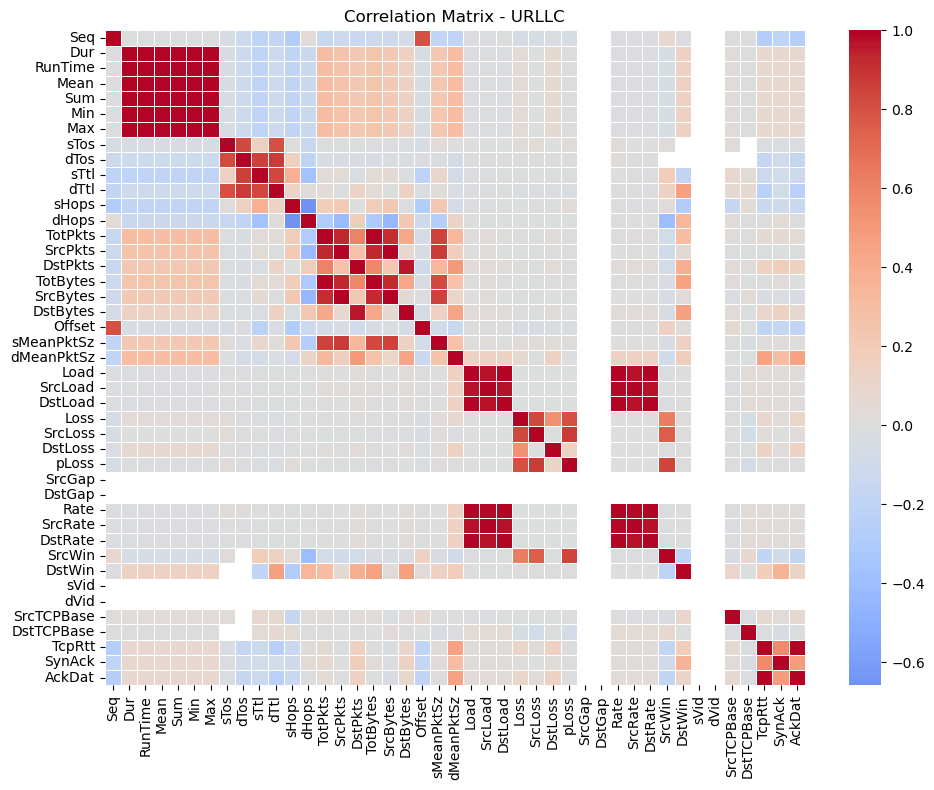

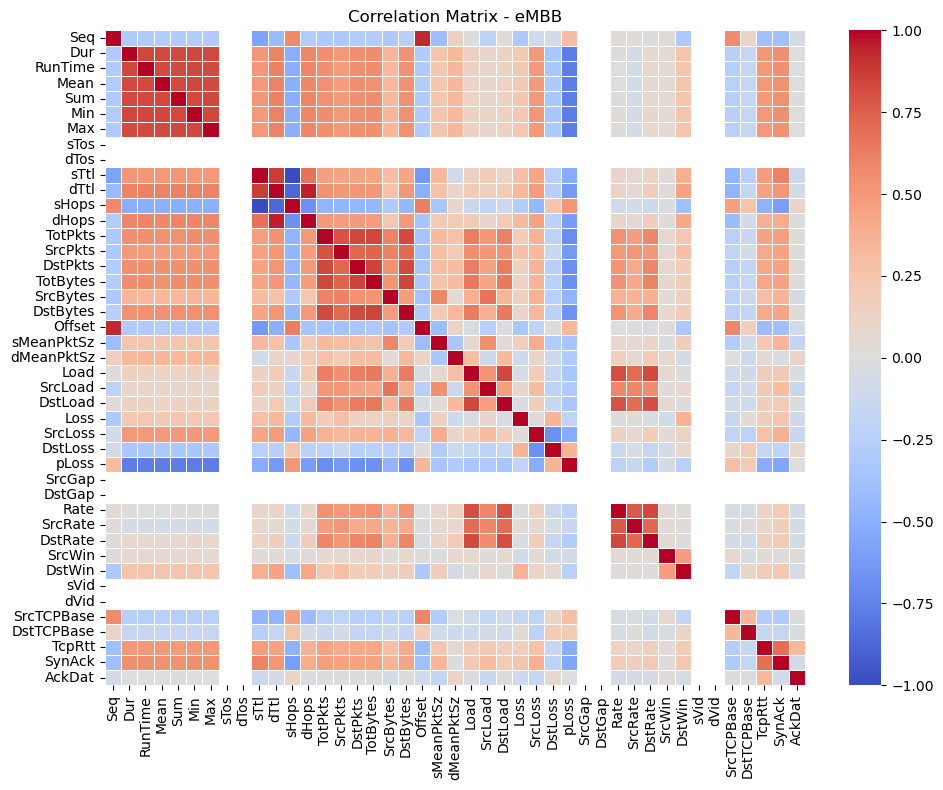

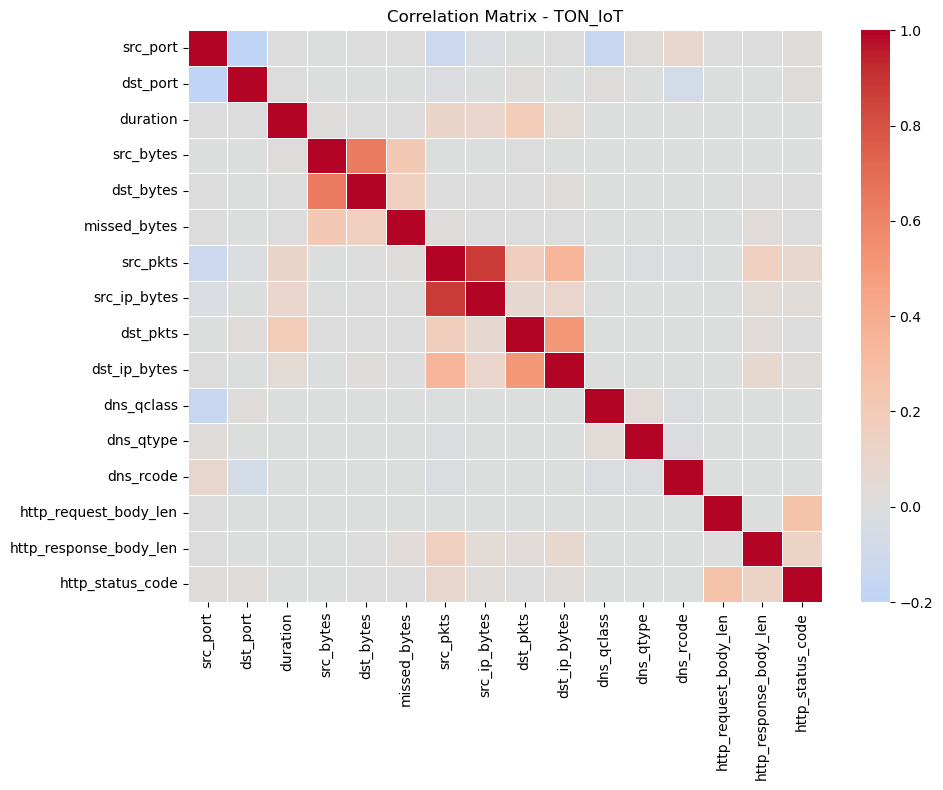

In [8]:
def plot_correlation_matrix(df, name):
    num = df.select_dtypes(include=[np.number]).copy()
    exclude = ['UniqueID','X','label_raw']
    num = num.drop(columns=[c for c in exclude if c in num.columns])
    if num.shape[1] < 2:
        print(f'Not enough numeric columns in {name}')
        return
    corr = num.corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
    plt.title(f'Correlation Matrix - {name}')
    plt.tight_layout()
    plt.show()

for n, d in datasets.items():
    plot_correlation_matrix(d, n)


## Data Preparation — Preprocessing Helpers
Per the Feature Justification Report, each feature group needs tailored preprocessing.
- **Volume / Rate / Timing**: Median impute → log1p → RobustScaler
- **Latency**: Median impute → RobustScaler
- **Loss**: Median impute → StandardScaler
- **Categorical**: Most-frequent impute → OneHotEncoder


## 🔍 Cell Description — Preprocessing Helpers (make_xy + build_preprocessor)

This is one of the most important cells in the notebook. It defines two reusable functions used by **every model training loop**.

---

### `make_xy(df)` — Feature/Target Split
Separates the DataFrame into features `X` and target `y`:
- **Drops** the label column (`Label`), metadata columns (`UniqueID`, `X`, `label_raw`, `predicted`), categorical identifiers (`type`, `anomaly_type`), network address columns (`SrcAddr`, `DstAddr`, `src_ip`, `dst_ip`, etc.), and timestamps.
- These columns are dropped because they are either the target variable, data leakage sources, or identifiers with no generalizable predictive value.
- Returns `X` (features only) and `y` (the `Label` string series).

---

### `build_preprocessor(X)` — Feature Transformation Pipeline
Builds a `ColumnTransformer` that applies different pipelines to numeric and categorical columns:

**Numeric pipeline (all float/int columns):**
1. `SimpleImputer(strategy='median')` — fills NaN with the column median (robust to outliers vs mean).
2. `FunctionTransformer(np.log1p)` — applies log(1 + x) transformation to compress right-skewed distributions (e.g., byte counts ranging from 0 to millions become 0–14).
3. `RobustScaler()` — scales using median and IQR instead of mean/std, so extreme outlier values (DDoS spikes) don't dominate the scale.

**Categorical pipeline (object/category columns):**
1. `SimpleImputer(strategy='most_frequent')` — fills NaN with the most common category.
2. `OneHotEncoder(handle_unknown='ignore')` — converts string categories (e.g., `proto='tcp'`) into binary indicator columns. `handle_unknown='ignore'` prevents crashes if the test set contains a category not seen during training.

**`remainder='drop'`** — any column not matched by either transformer is silently discarded.

---

**Key design principle:** The preprocessor is always fitted on `X_train` only, then applied to both `X_train` and `X_test`. This prevents **data leakage** — the scaler's median/IQR is computed from training data alone, not the test set.

In [9]:
log1p_transformer = FunctionTransformer(np.log1p, validate=False)

def make_xy(df, label_col='Label'):
    drop_cols = [label_col, 'label_raw', 'predicted', 'UniqueID', 'X',
                 'anomaly_type', 'type',
                 'SrcAddr','DstAddr','Sport','Dport',
                 'src_ip','dst_ip','src_port','dst_port',
                 'source_ip','destination_ip','timestamp']
    drop_cols = [c for c in drop_cols if c in df.columns]
    X = df.drop(columns=drop_cols, errors='ignore')
    y = df[label_col]
    return X, y

def build_preprocessor(X):
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('log1p',   log1p_transformer),
        ('scaler',  RobustScaler()),
    ])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    transformers = []
    if num_cols: transformers.append(('num', num_pipe, num_cols))
    if cat_cols: transformers.append(('cat', cat_pipe, cat_cols))
    return ColumnTransformer(transformers=transformers, remainder='drop')

print('Preprocessing helpers ready')


Preprocessing helpers ready


## 📌 Feature Selection
### Per-dataset feature sets based on the Feature Justification Report.


## 🔍 Cell Description — Feature Selection: eMBB

This cell defines the 8 features selected for the **eMBB (Enhanced Mobile Broadband)** dataset, based on the Feature Justification Report.

**eMBB context:** eMBB supports high-bandwidth services (4K video, VR). The primary attack vectors are **TCP SYN Flood** and **Bandwidth Saturation**. The selected features capture both handshake-level anomalies and volume overload:

| Feature | Type | Attack Signal |
|---|---|---|
| `Dur` | Timing | SYN Flood: very short duration (no full handshake) |
| `TotPkts` | Volume | SYN Flood: high packet count, low data |
| `TotBytes` | Volume | Bandwidth Saturation: massive byte transfer |
| `Rate` | Rate | Abnormally high packet rate = flooding |
| `Load` | Rate | Throughput load — saturation indicator |
| `Loss` | Loss | Packet drops correlate with overload |
| `pLoss` | Loss | Percentage loss > 4% → Bandwidth Saturation rule |
| `TcpRtt` | Latency | Very low RTT in SYN Flood (no ACK response) |

The code strips column name whitespace and verifies each feature exists in the DataFrame before finalizing the list (safe against dataset variants with different column sets).

In [10]:
# eMBB — Volume-Handshake Hybrid (12 → 8 selected)
df_embb = datasets['eMBB'].copy()
df_embb.columns = df_embb.columns.str.strip()
embb_features = ['Dur','TotPkts','TotBytes','Rate','Load','Loss','pLoss','TcpRtt']
embb_features = [c for c in embb_features if c in df_embb.columns]
print('eMBB features:', embb_features)
print('eMBB shape:', df_embb[embb_features].shape)


eMBB features: ['Dur', 'TotPkts', 'TotBytes', 'Rate', 'Load', 'Loss', 'pLoss', 'TcpRtt']
eMBB shape: (5808, 8)


## 🔍 Cell Description — Feature Selection: mMTC

This cell defines the 8 features for the **mMTC (Massive Machine Type Communications)** dataset.

**mMTC context:** mMTC serves IoT sensor networks with millions of small, infrequent transmissions. Attack patterns differ from eMBB — the concern is **connection flooding** and **slow-rate resource exhaustion** rather than bandwidth saturation.

| Feature | Type | Attack Signal |
|---|---|---|
| `TotPkts` | Volume | Scanning: < 10 packets per flow |
| `Rate` | Rate | Unusually high rate for "quiet" IoT traffic |
| `SrcGap` | Timing | Time gap between source packets — slow-rate attacks have long gaps |
| `DstGap` | Timing | Time gap between destination packets |
| `Dur` | Timing | Very short = SYN scan; very long + low load = slow exhaustion |
| `Load` | Rate | Low load with long duration = slow-rate attack signature |
| `Loss` | Loss | Packet loss under flooding |
| `TcpRtt` | Latency | Abnormal RTT during TCP-based scans |

The timing features (`SrcGap`, `DstGap`) are unique to mMTC and not selected for eMBB/URLLC — reflecting that timing irregularities are the primary discriminator in machine-type traffic.

In [11]:
# mMTC — Timing-Centric Minimal Set (8 features)
df_mmtc = datasets['mMTC'].copy()
df_mmtc.columns = df_mmtc.columns.str.strip()
mmtc_features = ['TotPkts','Rate','SrcGap','DstGap','Dur','Load','Loss','TcpRtt']
mmtc_features = [c for c in mmtc_features if c in df_mmtc.columns]
print('mMTC features:', mmtc_features)
print('mMTC shape:', df_mmtc[mmtc_features].shape)


mMTC features: ['TotPkts', 'Rate', 'SrcGap', 'DstGap', 'Dur', 'Load', 'Loss', 'TcpRtt']
mMTC shape: (4615, 8)


## 🔍 Cell Description — Feature Selection: URLLC

This cell defines the 8 features for the **URLLC (Ultra-Reliable Low Latency Communications)** dataset.

**URLLC context:** URLLC is the 6G slice for mission-critical applications (autonomous vehicles, remote surgery). Even a few milliseconds of latency violation can be catastrophic. Attacks here include **UDP DDoS Flood**, **RST Injection**, and **SLA Violation DoS**.

| Feature | Type | Attack Signal |
|---|---|---|
| `TcpRtt` | Latency | Primary indicator — RTT > 100ms = SLA violation |
| `SynAck` | Latency | TCP handshake time — anomalous if near zero (spoofed) or very high |
| `AckDat` | Latency | Time from ACK to first data — probing behavior |
| `Loss` | Loss | Packet loss = network disruption |
| `Dur` | Timing | Zero duration + 1 packet = UDP flood fingerprint |
| `Rate` | Rate | High rate = flooding |
| `TotPkts` | Volume | 1 packet at zero duration = UDP DDoS |
| `TotBytes` | Volume | Total data transferred |

The heavy focus on latency features (`TcpRtt`, `SynAck`, `AckDat`) reflects the latency-first priority of URLLC — these features don't appear together in mMTC or eMBB feature sets.

In [12]:
# URLLC — Latency-First Strategy (8 features)
df_urllc = datasets['URLLC'].copy()
df_urllc.columns = df_urllc.columns.str.strip()
urllc_features = ['TcpRtt','SynAck','AckDat','Loss','Dur','Rate','TotPkts','TotBytes']
urllc_features = [c for c in urllc_features if c in df_urllc.columns]
print('URLLC features:', urllc_features)
print('URLLC shape:', df_urllc[urllc_features].shape)


URLLC features: ['TcpRtt', 'SynAck', 'AckDat', 'Loss', 'Dur', 'Rate', 'TotPkts', 'TotBytes']
URLLC shape: (4033, 8)


## 🔍 Cell Description — Feature Selection: TON_IoT

This cell defines the 8 features for the **TON_IoT** dataset, which covers **9 named attack types** against real IoT network infrastructure.

**TON_IoT context:** Unlike the synthetic 6G slice datasets, TON_IoT uses real IoT network captures. It includes 9 attack types: DDoS, DoS, Scanning, Password (brute force), Backdoor, Ransomware, Injection, XSS, and MITM.

| Feature | Type | Attack Signal |
|---|---|---|
| `src_bytes` | Volume | DDoS/Ransomware: massive outbound data spike |
| `dst_bytes` | Volume | Backdoor/Ransomware: large C2 command responses inbound |
| `src_pkts` | Volume | Scanning: < 10 pkts; DDoS: burst > 1000 pkts |
| `dst_pkts` | Volume | Asymmetric src/dst ratio = attack fingerprint |
| `duration` | Timing | Backdoor: persistent long sessions (> 60s) |
| `proto` | Categorical | UDP = floods; unusual protocol = MITM |
| `conn_state` | Categorical | `REJ`/`RSTO` = scan/reset; `SF` = normal complete connection |
| `service` | Categorical | `ssh`/`ftp` = brute force; `http` = injection/XSS |

The presence of **two categorical features** (`proto`, `conn_state`, `service`) is unique to TON_IoT — these trigger the OneHotEncoder branch in `build_preprocessor()`. The comment explains why TON_IoT replaces the old G6/EENT dataset: 9 real attack types vs 3 synthetic ones.

In [13]:
# TON_IoT — IoT Behavioral Approach (8 features)
# Replaces old G6 (EENT) — 9 attack types vs 3, real IoT traffic vs synthetic
df_toniot = datasets['TON_IoT'].copy()
toniot_features = [
    'src_bytes',   # volume — DDoS/ransomware outbound spikes
    'dst_bytes',   # volume — C2 commands inbound (backdoor/ransomware)
    'src_pkts',    # packet count — scanning < 10 pkts, DDoS burst
    'dst_pkts',    # packet count — asymmetric response ratio
    'duration',    # timing — backdoor: persistent long sessions
    'proto',       # protocol — UDP floods, protocol mismatches
    'conn_state',  # TCP state — strongest discriminator (REJ=scan, SF=normal)
    'service',     # application layer — SSH=password, HTTP=injection/XSS
]
toniot_features = [c for c in toniot_features if c in df_toniot.columns]
print('TON_IoT features:', toniot_features)
print('TON_IoT shape:', df_toniot[toniot_features].shape)


TON_IoT features: ['src_bytes', 'dst_bytes', 'src_pkts', 'dst_pkts', 'duration', 'proto', 'conn_state', 'service']
TON_IoT shape: (210969, 8)


## 1️⃣ Random Forest (RF)
Ensemble model using bagging. Trained with `class_weight='balanced'`. TON_IoT additionally uses SMOTE before training.


## 🔍 Cell Description — Model Training: Random Forest

This is the **primary model training loop**. It trains a Random Forest classifier on each of the 4 datasets and collects results.

**Step-by-step walkthrough per dataset:**

1. **Feature filtering:** Keeps only the dataset-specific features from `FEATURE_MAP` that actually exist in the DataFrame (safe guard against column mismatches).

2. **Label encoding:** `LabelEncoder` converts `'Benign'`/`'Malicious'` string labels to `0`/`1` integers (required by sklearn).

3. **Train/test split:** 75% train, 25% test, `stratify=y_enc` ensures both splits maintain the same class ratio as the full dataset.

4. **Preprocessing:** `build_preprocessor()` is **fitted on `X_train` only** then applied to both sets — preventing data leakage.

5. **SMOTE (conditional):**
   - Computes imbalance ratio of the training set.
   - Applies SMOTE only if ratio > 2.0 **AND** the dataset is not TON_IoT (TON_IoT is excluded as an experiment — the comment marks this deliberate decision).
   - `sampling_strategy=0.5` means the minority class is upsampled to 50% of the majority class size (not full balance, which can cause overfitting).

6. **Random Forest hyperparameters:**
   - `n_estimators=200` — 200 trees (higher = more stable, slower)
   - `max_depth=15` — limits tree depth to prevent overfitting
   - `min_samples_leaf=5` — each leaf needs at least 5 samples (regularization)
   - `class_weight='balanced'` — automatically adjusts class weights inversely proportional to frequency (additional imbalance handling on top of SMOTE)

7. **Overfitting check:** Prints both train and test accuracy — a large gap (e.g., train=99%, test=70%) would indicate overfitting.

8. **Metrics collected:** Accuracy, F1 macro (average F1 across classes — robust to imbalance), ROC-AUC.

9. **Visualizations:** Side-by-side confusion matrix and ROC curve per dataset.

10. **Results stored** in `results_rf` list for the final comparison summary.


Dataset: mMTC
Model  : Random Forest
mMTC -> using 8 features
No SMOTE applied (ratio=1.14:1)
Train Accuracy: 0.9604160647211788
Test Accuracy : 0.9237435008665511
Accuracy : 0.9237
F1 macro : 0.9234
ROC-AUC  : 0.9796
              precision    recall  f1-score   support

      Benign       0.93      0.93      0.93       616
   Malicious       0.92      0.92      0.92       538

    accuracy                           0.92      1154
   macro avg       0.92      0.92      0.92      1154
weighted avg       0.92      0.92      0.92      1154



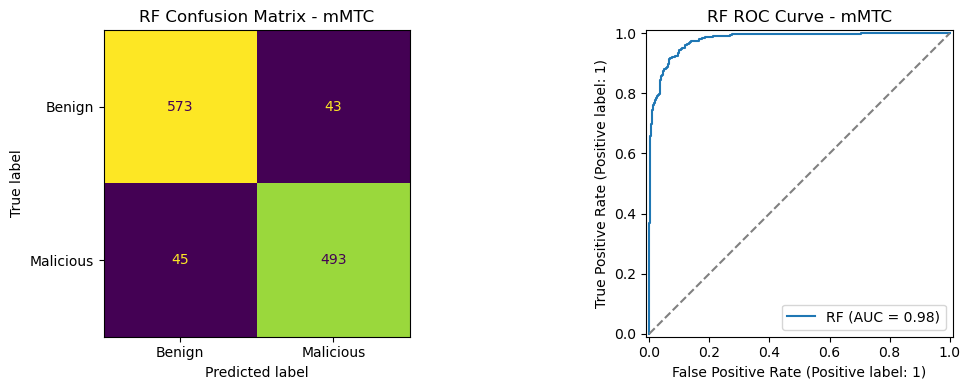


Dataset: URLLC
Model  : Random Forest
URLLC -> using 8 features
No SMOTE applied (ratio=1.56:1)
Train Accuracy: 0.7063492063492064
Test Accuracy : 0.6689791873141725
Accuracy : 0.6690
F1 macro : 0.6676
ROC-AUC  : 0.8371
              precision    recall  f1-score   support

      Benign       0.54      0.94      0.69       393
   Malicious       0.93      0.50      0.65       616

    accuracy                           0.67      1009
   macro avg       0.74      0.72      0.67      1009
weighted avg       0.78      0.67      0.66      1009



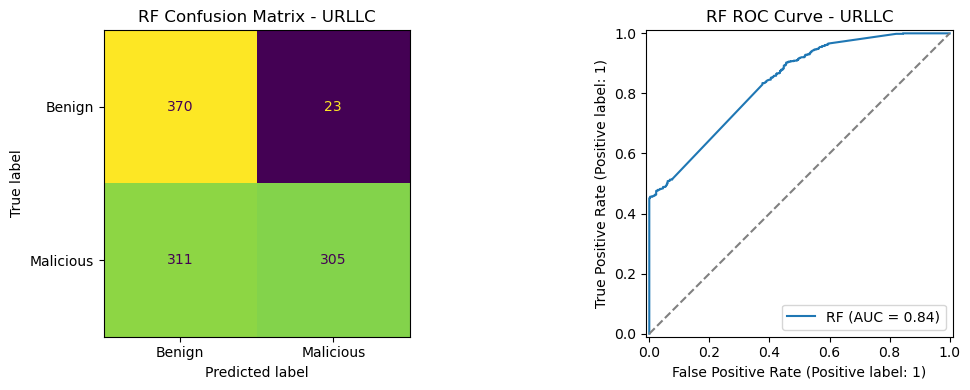


Dataset: eMBB
Model  : Random Forest
eMBB -> using 8 features
No SMOTE applied (ratio=1.09:1)
Train Accuracy: 0.9853076216712581
Test Accuracy : 0.9373278236914601
Accuracy : 0.9373
F1 macro : 0.9372
ROC-AUC  : 0.9908
              precision    recall  f1-score   support

      Benign       0.94      0.94      0.94       756
   Malicious       0.94      0.93      0.93       696

    accuracy                           0.94      1452
   macro avg       0.94      0.94      0.94      1452
weighted avg       0.94      0.94      0.94      1452



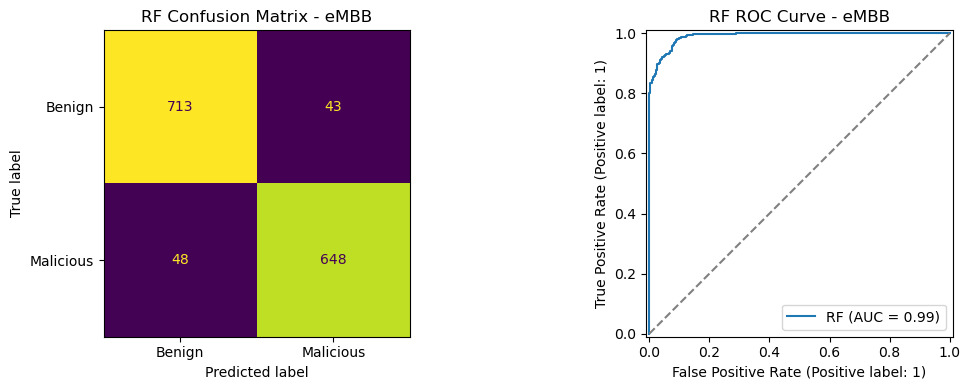


Dataset: TON_IoT
Model  : Random Forest
TON_IoT -> using 8 features
No SMOTE applied (ratio=3.22:1)
Train Accuracy: 0.9951904238241502
Test Accuracy : 0.9949756365773658
Accuracy : 0.9950
F1 macro : 0.9931
ROC-AUC  : 0.9993
              precision    recall  f1-score   support

      Benign       0.98      0.99      0.99     12496
   Malicious       1.00      1.00      1.00     40247

    accuracy                           0.99     52743
   macro avg       0.99      0.99      0.99     52743
weighted avg       1.00      0.99      0.99     52743



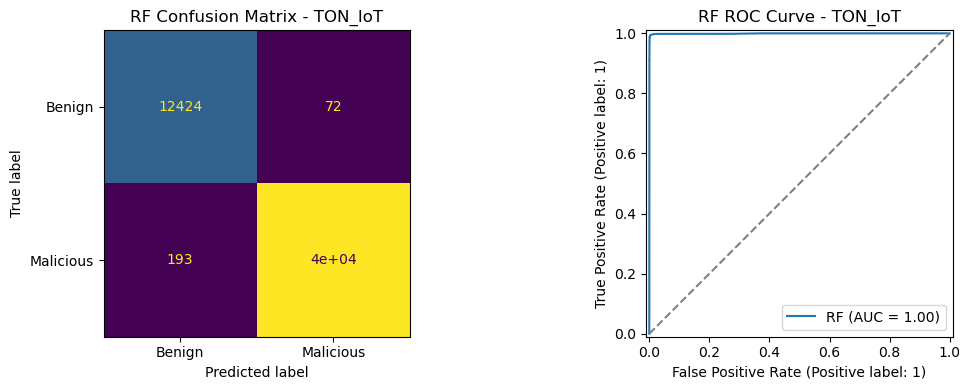

In [14]:
FEATURE_MAP = {
    'mMTC':    mmtc_features,
    'URLLC':   urllc_features,
    'eMBB':    embb_features,
    'TON_IoT': toniot_features,
}

# Imbalance ratio threshold above which SMOTE is applied
SMOTE_THRESHOLD = 2.0

results_rf = []

for name, df in datasets.items():
    print(f'\n==============================')
    print(f'Dataset: {name}')
    print(f'Model  : Random Forest')
    print(f'==============================')

    X, y = make_xy(df)
    keep = [c for c in FEATURE_MAP[name] if c in X.columns]
    X = X[keep]
    print(f'{name} -> using {len(keep)} features')

    # Encode label to int
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
    )

    pre = build_preprocessor(X_train)
    X_train_proc = pre.fit_transform(X_train)
    X_test_proc  = pre.transform(X_test)

    # Apply SMOTE only when imbalance ratio exceeds threshold
    counts = pd.Series(y_train).value_counts()
    ratio  = counts.max() / counts.min()
    # Apply SMOTE only when needed AND skip for TON_IoT (experiment)
    if name != 'TON_IoT' and ratio > SMOTE_THRESHOLD:
        print(f'Applying SMOTE (ratio={ratio:.2f}:1)...')
        sm = SMOTE(sampling_strategy=0.5, random_state=42)
        X_train_proc, y_train = sm.fit_resample(X_train_proc, y_train)
    else:
        print(f'No SMOTE applied (ratio={ratio:.2f}:1)')
    model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
    model.fit(X_train_proc, y_train)
    # Overfitting check
    train_pred = model.predict(X_train_proc)
    test_pred  = model.predict(X_test_proc)

    print("Train Accuracy:", accuracy_score(y_train, train_pred))
    print("Test Accuracy :", accuracy_score(y_test, test_pred))
    y_pred  = model.predict(X_test_proc)
    y_proba = model.predict_proba(X_test_proc)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, y_proba)
    print(f'Accuracy : {acc:.4f}')
    print(f'F1 macro : {f1:.4f}')
    print(f'ROC-AUC  : {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=le.classes_,
        ax=axes[0], colorbar=False
    )
    axes[0].set_title(f'RF Confusion Matrix - {name}')
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name='RF')
    axes[1].plot([0,1],[0,1],'--',color='gray')
    axes[1].set_title(f'RF ROC Curve - {name}')
    plt.tight_layout()
    plt.show()

    results_rf.append({'Dataset':name,'Model':'RandomForest',
                       'Accuracy':acc,'F1_macro':f1,'ROC_AUC':auc})


## 2️⃣ XGBoost (Gradient Boosting)
Advanced boosted trees. Uses `scale_pos_weight` for imbalanced datasets in addition to SMOTE.


## 🔍 Cell Description — Model Training: XGBoost

This cell replicates the training loop for **XGBoost (eXtreme Gradient Boosting)** — a boosting-based ensemble that builds trees sequentially, each correcting the errors of the previous.

**Key differences from Random Forest (Cell 26):**

| Aspect | Random Forest | XGBoost |
|---|---|---|
| Algorithm | Bagging (parallel trees) | Boosting (sequential trees) |
| Imbalance handling | `class_weight='balanced'` | `scale_pos_weight` parameter |
| SMOTE fallback | After SMOTE, no extra weight | `spw=1.0` after SMOTE (already balanced) |
| Hyperparameters | 200 trees, max_depth=15 | 300 trees, scale_pos_weight=ratio |

**`scale_pos_weight` logic:**
- If SMOTE was applied → classes are already balanced → `spw = 1.0` (no additional weighting).
- If SMOTE was NOT applied → `spw = ratio` (majority/minority count ratio) — XGBoost's built-in way to penalize misclassifying the minority class more heavily.

**Fallback:** If XGBoost is not installed (`USE_XGBOOST = False`), the loop uses `GradientBoostingClassifier` from sklearn instead (same concept, slower, no GPU support).

**Output per dataset:** Same as RF — accuracy/F1/AUC printed, confusion matrix and ROC curve plotted, results appended to `results_xgb`.


Dataset: mMTC
Model  : XGBoost
Accuracy : 0.9255
F1 macro : 0.9252
ROC-AUC  : 0.9791
              precision    recall  f1-score   support

      Benign       0.93      0.93      0.93       616
   Malicious       0.92      0.92      0.92       538

    accuracy                           0.93      1154
   macro avg       0.93      0.93      0.93      1154
weighted avg       0.93      0.93      0.93      1154



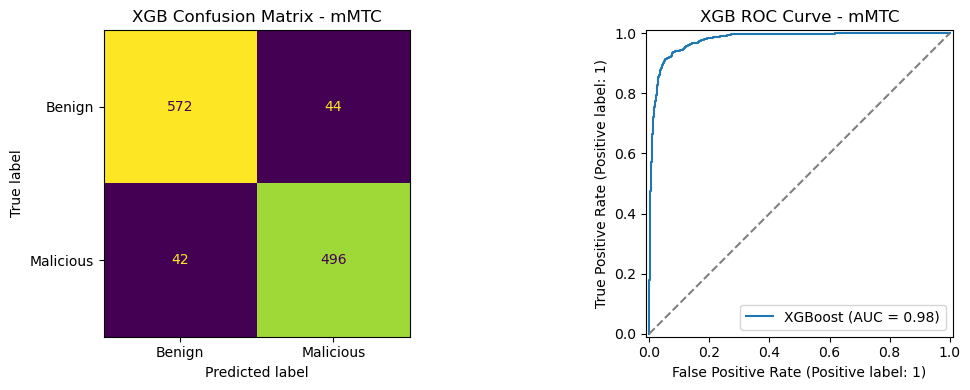


Dataset: URLLC
Model  : XGBoost
Accuracy : 0.7522
F1 macro : 0.7090
ROC-AUC  : 0.8370
              precision    recall  f1-score   support

      Benign       0.81      0.47      0.60       393
   Malicious       0.73      0.93      0.82       616

    accuracy                           0.75      1009
   macro avg       0.77      0.70      0.71      1009
weighted avg       0.77      0.75      0.73      1009



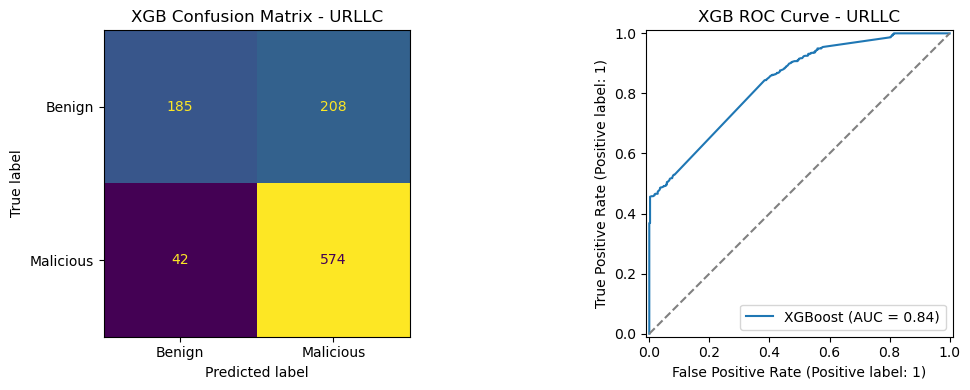


Dataset: eMBB
Model  : XGBoost
Accuracy : 0.9470
F1 macro : 0.9469
ROC-AUC  : 0.9908
              precision    recall  f1-score   support

      Benign       0.95      0.95      0.95       756
   Malicious       0.94      0.95      0.94       696

    accuracy                           0.95      1452
   macro avg       0.95      0.95      0.95      1452
weighted avg       0.95      0.95      0.95      1452



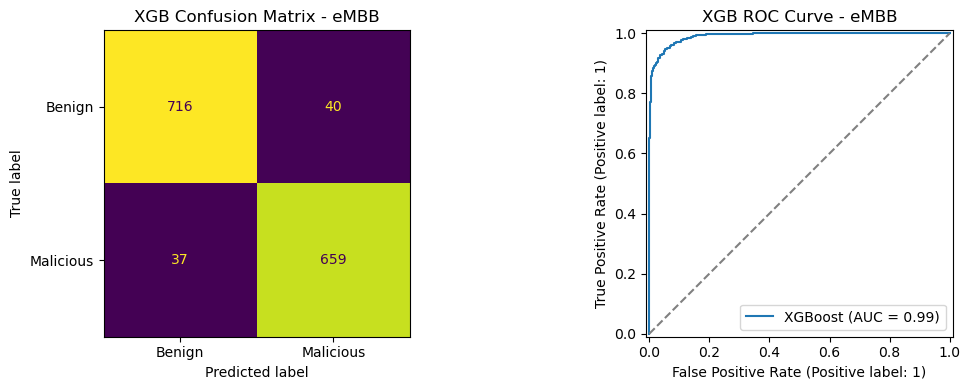


Dataset: TON_IoT
Model  : XGBoost
Accuracy : 0.9959
F1 macro : 0.9944
ROC-AUC  : 0.9998
              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99     12496
   Malicious       1.00      1.00      1.00     40247

    accuracy                           1.00     52743
   macro avg       0.99      1.00      0.99     52743
weighted avg       1.00      1.00      1.00     52743



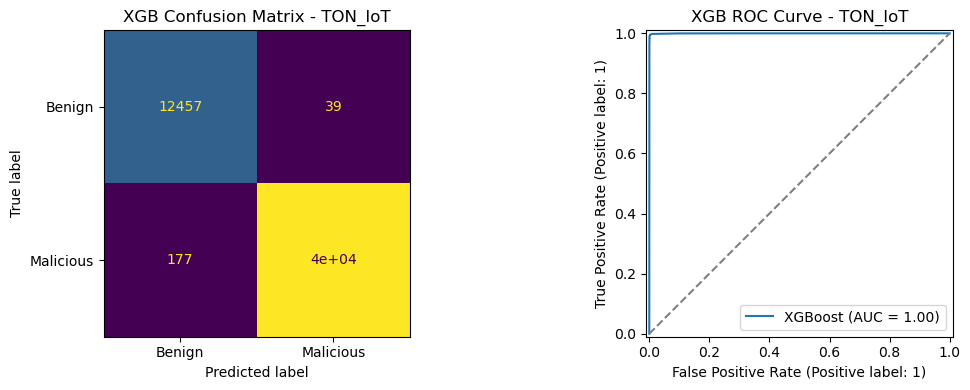

In [15]:
results_xgb = []

for name, df in datasets.items():
    print(f'\n==============================')
    print(f'Dataset: {name}')
    print(f'Model  : XGBoost')
    print(f'==============================')

    X, y = make_xy(df)
    keep = [c for c in FEATURE_MAP[name] if c in X.columns]
    X = X[keep]

    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
    )

    pre = build_preprocessor(X_train)
    X_train_proc = pre.fit_transform(X_train)
    X_test_proc  = pre.transform(X_test)

    counts = pd.Series(y_train).value_counts()
    ratio  = counts.max() / counts.min()
    if ratio > SMOTE_THRESHOLD:
        sm = SMOTE(random_state=42)
        X_train_proc, y_train = sm.fit_resample(X_train_proc, y_train)
        spw = 1.0  # already balanced after SMOTE
    else:
        spw = ratio

    if USE_XGBOOST:
        model = XGBClassifier(
            n_estimators=300, random_state=42, n_jobs=-1,
            scale_pos_weight=spw, eval_metric='logloss', verbosity=0
        )
    else:
        model = GradientBoostingClassifier(n_estimators=200, random_state=42)

    model.fit(X_train_proc, y_train)
    y_pred  = model.predict(X_test_proc)
    y_proba = model.predict_proba(X_test_proc)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, y_proba)
    print(f'Accuracy : {acc:.4f}')
    print(f'F1 macro : {f1:.4f}')
    print(f'ROC-AUC  : {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=le.classes_,
        ax=axes[0], colorbar=False
    )
    axes[0].set_title(f'XGB Confusion Matrix - {name}')
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name='XGBoost')
    axes[1].plot([0,1],[0,1],'--',color='gray')
    axes[1].set_title(f'XGB ROC Curve - {name}')
    plt.tight_layout()
    plt.show()

    results_xgb.append({'Dataset':name,'Model':'XGBoost',
                        'Accuracy':acc,'F1_macro':f1,'ROC_AUC':auc})


## 3️⃣ Logistic Regression (Baseline)
Linear classifier used as baseline. Simple, fast, interpretable.


## 🔍 Cell Description — Model Training: Logistic Regression (Baseline)

This cell trains a **Logistic Regression** classifier as the baseline model. It follows the same structure as the RF and XGBoost loops for consistent comparison.

**Purpose of a baseline:**
- Establishes the minimum acceptable performance. If RF/XGBoost don't significantly outperform Logistic Regression, the added complexity is not justified.
- Logistic Regression is interpretable (coefficients show feature importance directly) — useful for validating that the preprocessing and feature selection are sensible.

**Key configuration:**
- `max_iter=1000` — increased from the default 100 because the log1p + scaling pipeline produces well-conditioned data but convergence can still take more iterations with many features.
- `class_weight='balanced'` — same imbalance handling as RF.
- SMOTE applied if ratio > 2.0 (same threshold as RF/XGBoost).

**What to watch for in results:** Logistic Regression is a *linear* model — it cannot capture non-linear decision boundaries. For network intrusion detection where attack behavior creates non-linear patterns (e.g., DDoS requires both high rate AND low duration simultaneously), LR will likely underperform RF and XGBoost, confirming the value of the ensemble models.


Dataset: mMTC
Model  : Logistic Regression
Accuracy : 0.8830
F1 macro : 0.8829
ROC-AUC  : 0.9458
              precision    recall  f1-score   support

      Benign       0.92      0.86      0.89       616
   Malicious       0.85      0.91      0.88       538

    accuracy                           0.88      1154
   macro avg       0.88      0.88      0.88      1154
weighted avg       0.89      0.88      0.88      1154



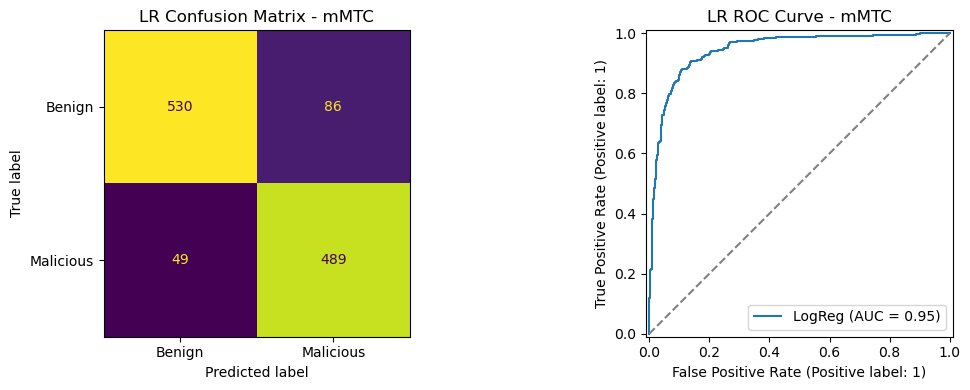


Dataset: URLLC
Model  : Logistic Regression
Accuracy : 0.5362
F1 macro : 0.5360
ROC-AUC  : 0.6452
              precision    recall  f1-score   support

      Benign       0.44      0.66      0.53       393
   Malicious       0.68      0.46      0.55       616

    accuracy                           0.54      1009
   macro avg       0.56      0.56      0.54      1009
weighted avg       0.58      0.54      0.54      1009



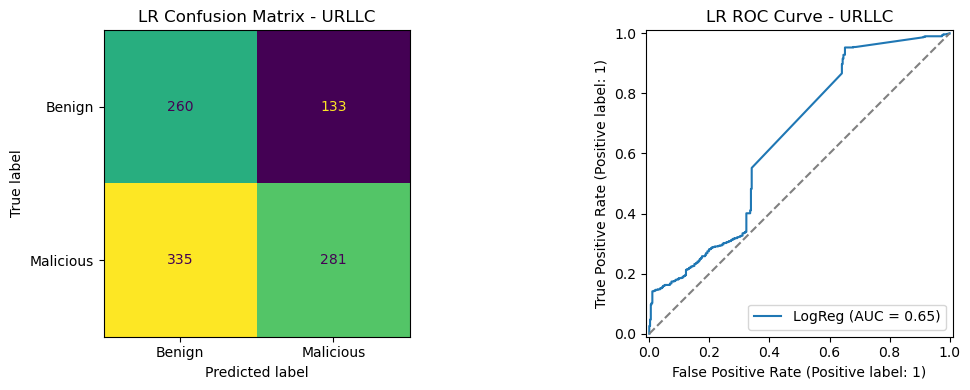


Dataset: eMBB
Model  : Logistic Regression
Accuracy : 0.8478
F1 macro : 0.8478
ROC-AUC  : 0.9277
              precision    recall  f1-score   support

      Benign       0.87      0.83      0.85       756
   Malicious       0.82      0.87      0.85       696

    accuracy                           0.85      1452
   macro avg       0.85      0.85      0.85      1452
weighted avg       0.85      0.85      0.85      1452



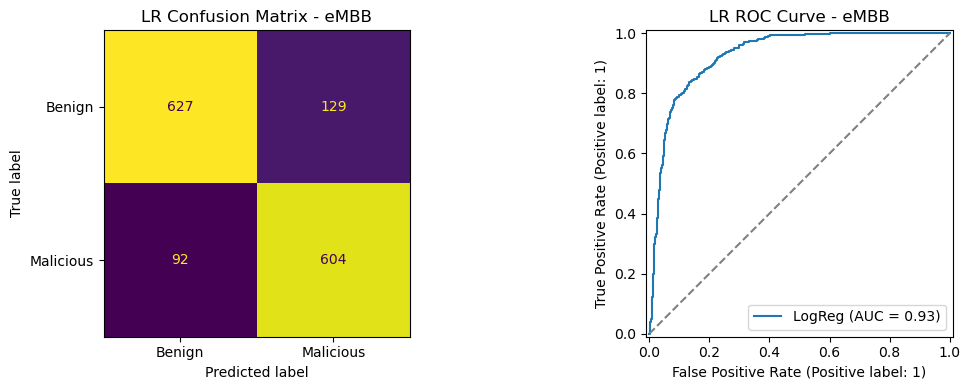


Dataset: TON_IoT
Model  : Logistic Regression
Accuracy : 0.9042
F1 macro : 0.8810
ROC-AUC  : 0.9686
              precision    recall  f1-score   support

      Benign       0.72      0.98      0.83     12496
   Malicious       0.99      0.88      0.93     40247

    accuracy                           0.90     52743
   macro avg       0.86      0.93      0.88     52743
weighted avg       0.93      0.90      0.91     52743



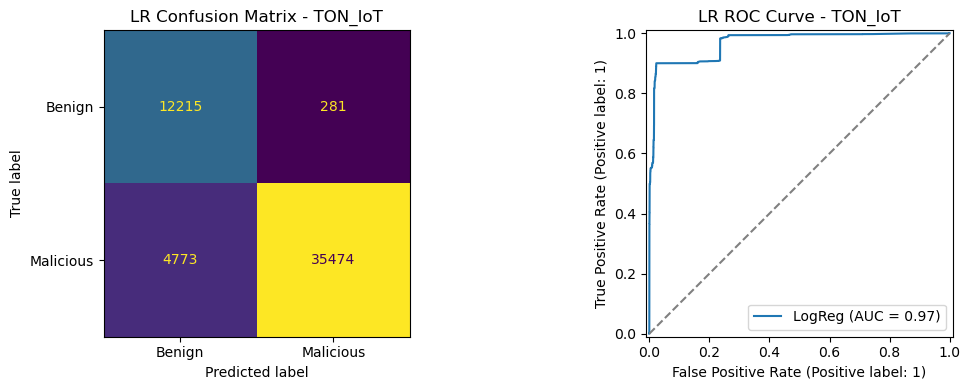

In [16]:
results_lr = []

for name, df in datasets.items():
    print(f'\n==============================')
    print(f'Dataset: {name}')
    print(f'Model  : Logistic Regression')
    print(f'==============================')

    X, y = make_xy(df)
    keep = [c for c in FEATURE_MAP[name] if c in X.columns]
    X = X[keep]

    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
    )

    pre = build_preprocessor(X_train)
    X_train_proc = pre.fit_transform(X_train)
    X_test_proc  = pre.transform(X_test)

    counts = pd.Series(y_train).value_counts()
    ratio  = counts.max() / counts.min()
    if ratio > SMOTE_THRESHOLD:
        sm = SMOTE(random_state=42)
        X_train_proc, y_train = sm.fit_resample(X_train_proc, y_train)

    model = LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    )
    model.fit(X_train_proc, y_train)
    y_pred  = model.predict(X_test_proc)
    y_proba = model.predict_proba(X_test_proc)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, y_proba)
    print(f'Accuracy : {acc:.4f}')
    print(f'F1 macro : {f1:.4f}')
    print(f'ROC-AUC  : {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=le.classes_,
        ax=axes[0], colorbar=False
    )
    axes[0].set_title(f'LR Confusion Matrix - {name}')
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name='LogReg')
    axes[1].plot([0,1],[0,1],'--',color='gray')
    axes[1].set_title(f'LR ROC Curve - {name}')
    plt.tight_layout()
    plt.show()

    results_lr.append({'Dataset':name,'Model':'LogisticRegression',
                       'Accuracy':acc,'F1_macro':f1,'ROC_AUC':auc})


## 4⃣ Extra Trees Classifier
Ensemble of fully randomized trees. Faster than Random Forest due to random split thresholds.
Uses `class_weight='balanced'` and SMOTE for imbalanced datasets — same protocol as RF.

## 🔍 Cell Description — Model Training: Extra Trees

Extra Trees (Extremely Randomized Trees) differs from Random Forest in one key way: instead of finding the **best** split threshold for each feature, it picks a **random** threshold. This makes it:
- **Faster** to train (no threshold search)
- **Less prone to overfitting** on noisy IDS data
- **Comparable or better** on high-dimensional feature spaces

The training loop is identical to RF in structure — SMOTE + `class_weight='balanced'` + same train/test split.


Dataset: mMTC
Model  : Extra Trees
No SMOTE applied (ratio=1.14:1)
Train Accuracy: 0.9179427911008379
Test Accuracy : 0.9098786828422877
Accuracy : 0.9099
F1 macro : 0.9096
ROC-AUC  : 0.9687
              precision    recall  f1-score   support

      Benign       0.93      0.90      0.91       616
   Malicious       0.89      0.92      0.90       538

    accuracy                           0.91      1154
   macro avg       0.91      0.91      0.91      1154
weighted avg       0.91      0.91      0.91      1154



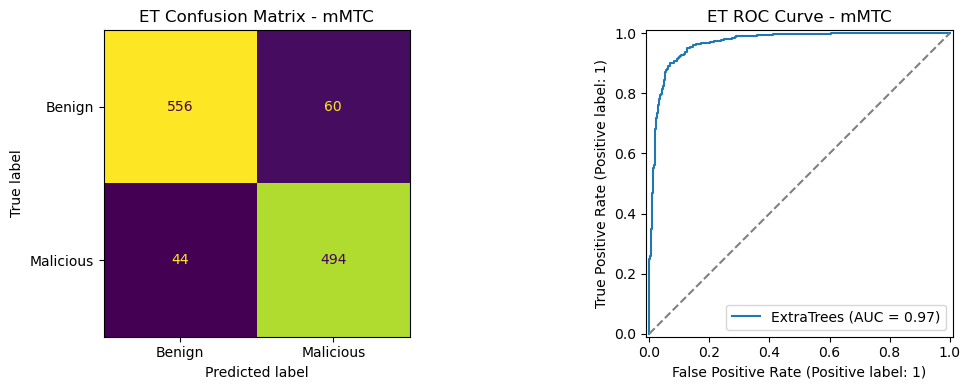


Dataset: URLLC
Model  : Extra Trees
No SMOTE applied (ratio=1.56:1)
Train Accuracy: 0.6531084656084656
Test Accuracy : 0.647175421209118
Accuracy : 0.6472
F1 macro : 0.6424
ROC-AUC  : 0.8001
              precision    recall  f1-score   support

      Benign       0.53      0.98      0.68       393
   Malicious       0.97      0.44      0.60       616

    accuracy                           0.65      1009
   macro avg       0.75      0.71      0.64      1009
weighted avg       0.80      0.65      0.63      1009



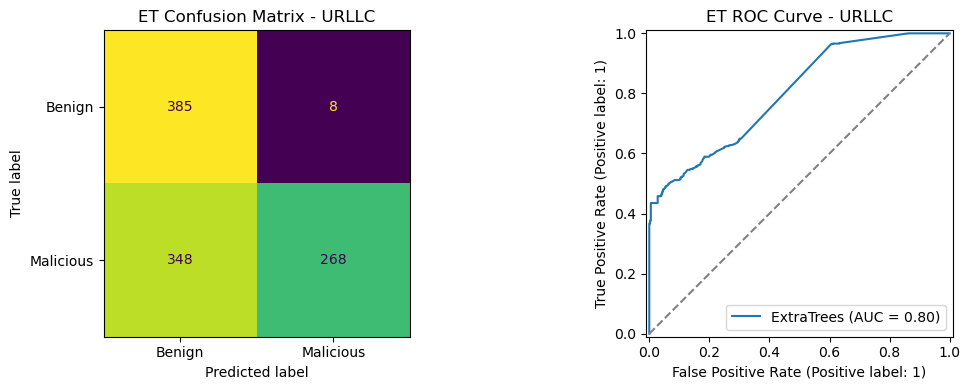


Dataset: eMBB
Model  : Extra Trees
No SMOTE applied (ratio=1.09:1)
Train Accuracy: 0.9090909090909091
Test Accuracy : 0.8891184573002755
Accuracy : 0.8891
F1 macro : 0.8888
ROC-AUC  : 0.9740
              precision    recall  f1-score   support

      Benign       0.88      0.91      0.89       756
   Malicious       0.90      0.87      0.88       696

    accuracy                           0.89      1452
   macro avg       0.89      0.89      0.89      1452
weighted avg       0.89      0.89      0.89      1452



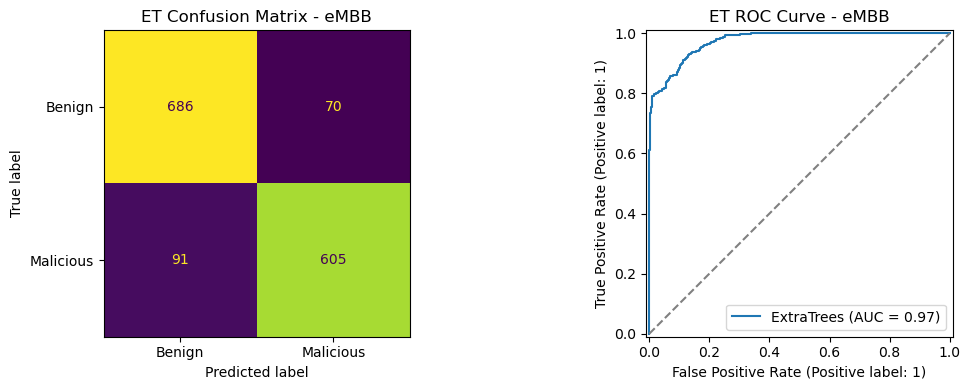


Dataset: TON_IoT
Model  : Extra Trees
No SMOTE applied (ratio=3.22:1)
Train Accuracy: 0.9669396938556243
Test Accuracy : 0.966952960582447
Accuracy : 0.9670
F1 macro : 0.9558
ROC-AUC  : 0.9950
              precision    recall  f1-score   support

      Benign       0.89      0.98      0.93     12496
   Malicious       0.99      0.96      0.98     40247

    accuracy                           0.97     52743
   macro avg       0.94      0.97      0.96     52743
weighted avg       0.97      0.97      0.97     52743



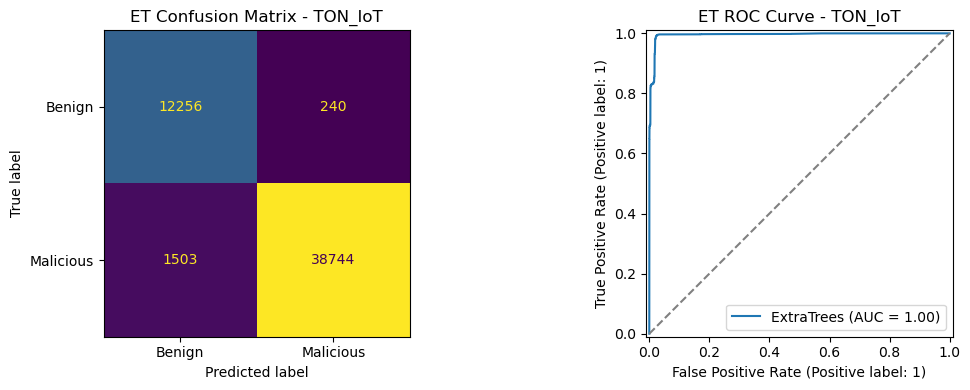

In [17]:
results_et = []

for name, df in datasets.items():
    print(f'\n==============================')
    print(f'Dataset: {name}')
    print(f'Model  : Extra Trees')
    print(f'==============================')

    X, y = make_xy(df)
    keep = [c for c in FEATURE_MAP[name] if c in X.columns]
    X = X[keep]

    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
    )

    pre = build_preprocessor(X_train)
    X_train_proc = pre.fit_transform(X_train)
    X_test_proc  = pre.transform(X_test)

    counts = pd.Series(y_train).value_counts()
    ratio  = counts.max() / counts.min()
    if name != 'TON_IoT' and ratio > SMOTE_THRESHOLD:
        print(f'Applying SMOTE (ratio={ratio:.2f}:1)...')
        sm = SMOTE(sampling_strategy=0.5, random_state=42)
        X_train_proc, y_train = sm.fit_resample(X_train_proc, y_train)
    else:
        print(f'No SMOTE applied (ratio={ratio:.2f}:1)')

    model = ExtraTreesClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    )
    model.fit(X_train_proc, y_train)

    train_pred = model.predict(X_train_proc)
    test_pred  = model.predict(X_test_proc)
    print('Train Accuracy:', accuracy_score(y_train, train_pred))
    print('Test Accuracy :', accuracy_score(y_test, test_pred))

    y_pred  = model.predict(X_test_proc)
    y_proba = model.predict_proba(X_test_proc)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, y_proba)
    print(f'Accuracy : {acc:.4f}')
    print(f'F1 macro : {f1:.4f}')
    print(f'ROC-AUC  : {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=le.classes_,
        ax=axes[0], colorbar=False
    )
    axes[0].set_title(f'ET Confusion Matrix - {name}')
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name='ExtraTrees')
    axes[1].plot([0,1],[0,1],'--',color='gray')
    axes[1].set_title(f'ET ROC Curve - {name}')
    plt.tight_layout()
    plt.show()

    results_et.append({'Dataset':name,'Model':'ExtraTrees',
                       'Accuracy':acc,'F1_macro':f1,'ROC_AUC':auc})


## 5⃣ MLP Neural Network
Multi-Layer Perceptron with two hidden layers `(128, 64)`. Captures non-linear feature
interactions that tree-based models may miss. Early stopping prevents overfitting.

## 🔍 Cell Description — Model Training: MLP (Neural Network)

The MLP (Multi-Layer Perceptron) is a fully connected feedforward neural network trained with backpropagation.

**Architecture:**
- Hidden layers: `(128, 64)` — two layers to learn hierarchical attack patterns
- Activation: `relu` — fast and effective for tabular data
- Solver: `adam` — adaptive learning rate, handles sparse gradients
- Early stopping: enabled — avoids overfitting by monitoring validation loss

**Why it complements tree models:**
- Learns **continuous feature boundaries** rather than axis-aligned splits
- Better at detecting **novel attack patterns** with mixed feature signals across slices
- The same SMOTE protocol is applied to handle class imbalance before training.


Dataset: mMTC
Model  : MLP Neural Network
No SMOTE applied (ratio=1.14:1)
Accuracy : 0.8951
F1 macro : 0.8947
ROC-AUC  : 0.9603
              precision    recall  f1-score   support

      Benign       0.91      0.90      0.90       616
   Malicious       0.88      0.89      0.89       538

    accuracy                           0.90      1154
   macro avg       0.89      0.90      0.89      1154
weighted avg       0.90      0.90      0.90      1154



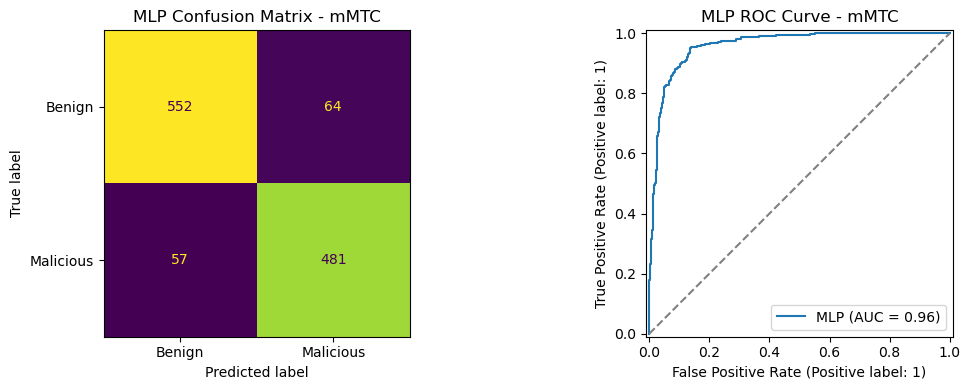


Dataset: URLLC
Model  : MLP Neural Network
No SMOTE applied (ratio=1.56:1)
Accuracy : 0.7146
F1 macro : 0.6384
ROC-AUC  : 0.6955
              precision    recall  f1-score   support

      Benign       0.84      0.33      0.47       393
   Malicious       0.69      0.96      0.80       616

    accuracy                           0.71      1009
   macro avg       0.77      0.64      0.64      1009
weighted avg       0.75      0.71      0.68      1009



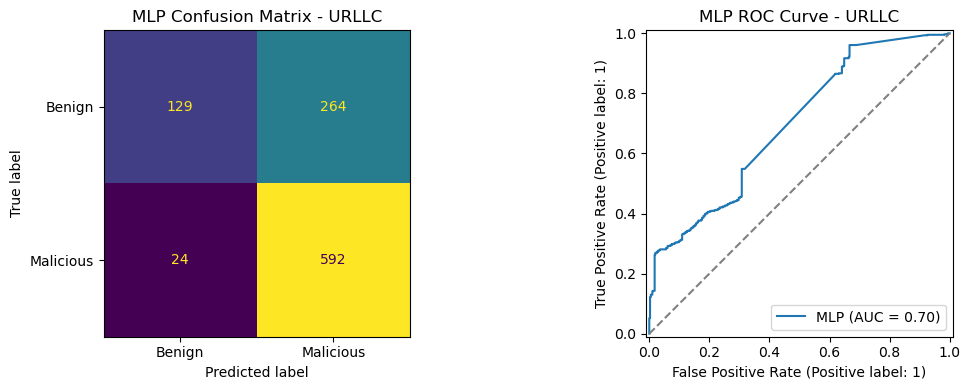


Dataset: eMBB
Model  : MLP Neural Network
No SMOTE applied (ratio=1.09:1)
Accuracy : 0.8740
F1 macro : 0.8738
ROC-AUC  : 0.9592
              precision    recall  f1-score   support

      Benign       0.88      0.87      0.88       756
   Malicious       0.86      0.87      0.87       696

    accuracy                           0.87      1452
   macro avg       0.87      0.87      0.87      1452
weighted avg       0.87      0.87      0.87      1452



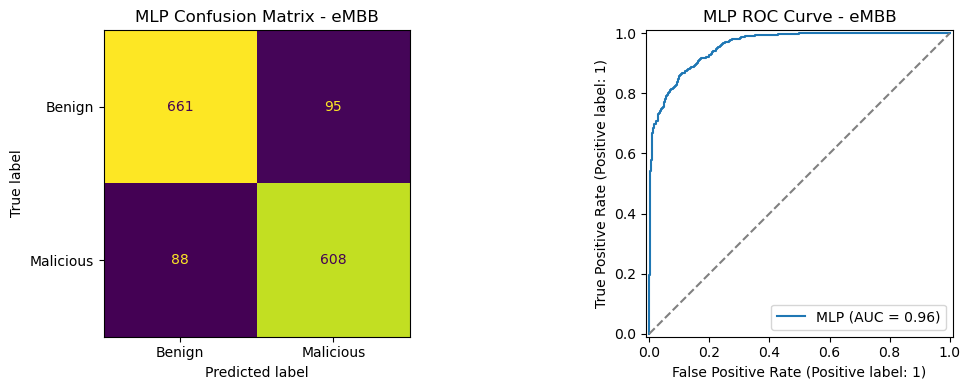


Dataset: TON_IoT
Model  : MLP Neural Network
Applying SMOTE (ratio=3.22:1)...
Accuracy : 0.9931
F1 macro : 0.9905
ROC-AUC  : 0.9994
              precision    recall  f1-score   support

      Benign       0.98      0.99      0.99     12496
   Malicious       1.00      0.99      1.00     40247

    accuracy                           0.99     52743
   macro avg       0.99      0.99      0.99     52743
weighted avg       0.99      0.99      0.99     52743



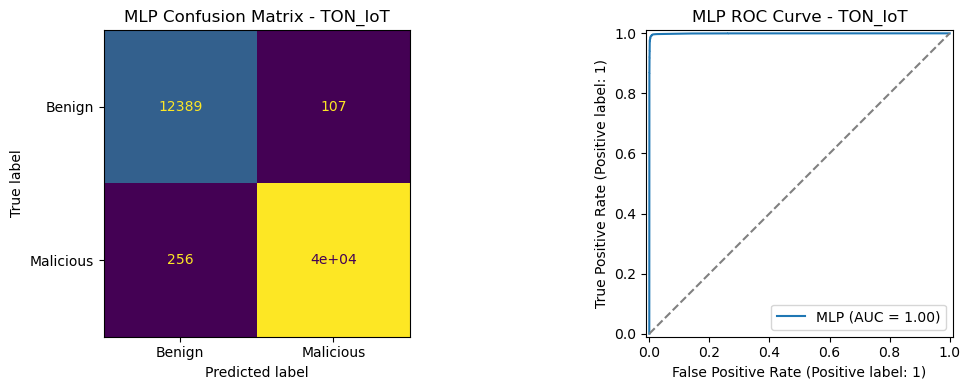

In [18]:
results_mlp = []

for name, df in datasets.items():
    print(f'\n==============================')
    print(f'Dataset: {name}')
    print(f'Model  : MLP Neural Network')
    print(f'==============================')

    X, y = make_xy(df)
    keep = [c for c in FEATURE_MAP[name] if c in X.columns]
    X = X[keep]

    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
    )

    pre = build_preprocessor(X_train)
    X_train_proc = pre.fit_transform(X_train)
    X_test_proc  = pre.transform(X_test)

    counts = pd.Series(y_train).value_counts()
    ratio  = counts.max() / counts.min()
    if ratio > SMOTE_THRESHOLD:
        print(f'Applying SMOTE (ratio={ratio:.2f}:1)...')
        sm = SMOTE(random_state=42)
        X_train_proc, y_train = sm.fit_resample(X_train_proc, y_train)
    else:
        print(f'No SMOTE applied (ratio={ratio:.2f}:1)')

    model = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # smaller network → faster
    activation='relu',
    solver='adam',
    max_iter=200,                  # reduce max iterations
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,           # stop sooner if no improvement
    batch_size=512,                # larger batches → fewer updates per epoch
    verbose=False
)
    model.fit(X_train_proc, y_train)

    y_pred  = model.predict(X_test_proc)
    y_proba = model.predict_proba(X_test_proc)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, y_proba)
    print(f'Accuracy : {acc:.4f}')
    print(f'F1 macro : {f1:.4f}')
    print(f'ROC-AUC  : {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=le.classes_,
        ax=axes[0], colorbar=False
    )
    axes[0].set_title(f'MLP Confusion Matrix - {name}')
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name='MLP')
    axes[1].plot([0,1],[0,1],'--',color='gray')
    axes[1].set_title(f'MLP ROC Curve - {name}')
    plt.tight_layout()
    plt.show()

    results_mlp.append({'Dataset':name,'Model':'MLP',
                        'Accuracy':acc,'F1_macro':f1,'ROC_AUC':auc})


## 6⃣ LightGBM (Gradient Boosting — Leaf-wise)
Histogram-based gradient boosting. Builds trees **leaf-wise** (best-first)
instead of level-wise like XGBoost, making it 3–10× faster with lower memory usage.
- `n_estimators=300` with early stopping (patience=30)
- `num_leaves=63` — controls model complexity
- `scale_pos_weight` — handles class imbalance natively
- SMOTE applied when imbalance ratio > `SMOTE_THRESHOLD` (same protocol as RF/ET)


## 🔍 Cell Description — Model Training: LightGBM

This cell trains a **LightGBM** classifier on each of the 4 datasets.

**How LightGBM differs from other models in this notebook:**

| Aspect | LightGBM vs others |
|---|---|
| Tree growth | Leaf-wise (best-first) vs level-wise (XGBoost) |
| Speed | 3–10× faster than XGBoost on large datasets |
| Memory | Histogram binning reduces memory by ~8× vs exact split |
| Early stopping | Native — stops when eval metric stops improving |
| Imbalance | `scale_pos_weight` multiplies minority class gradient |

**Key hyperparameters:**
- `n_estimators=300` — maximum number of boosting rounds
- `learning_rate=0.05` — shrinkage applied to each tree contribution
- `num_leaves=63` — max leaves per tree (controls complexity)
- `min_child_samples=20` — minimum samples in a leaf (prevents overfitting)
- `scale_pos_weight=ratio` — set to class imbalance ratio when no SMOTE
- `early_stopping(30)` — stops if validation loss does not improve for 30 rounds



Dataset: mMTC
Model  : LightGBM
mMTC -> using 8 features, 4615 rows
No SMOTE applied (ratio=1.14:1)
Train Accuracy: 0.9985553308292401
Test  Accuracy: 0.9306759098786829
Accuracy : 0.9307
F1 macro : 0.9304
ROC-AUC  : 0.9818
              precision    recall  f1-score   support

      Benign       0.94      0.93      0.93       616
   Malicious       0.92      0.93      0.93       538

    accuracy                           0.93      1154
   macro avg       0.93      0.93      0.93      1154
weighted avg       0.93      0.93      0.93      1154



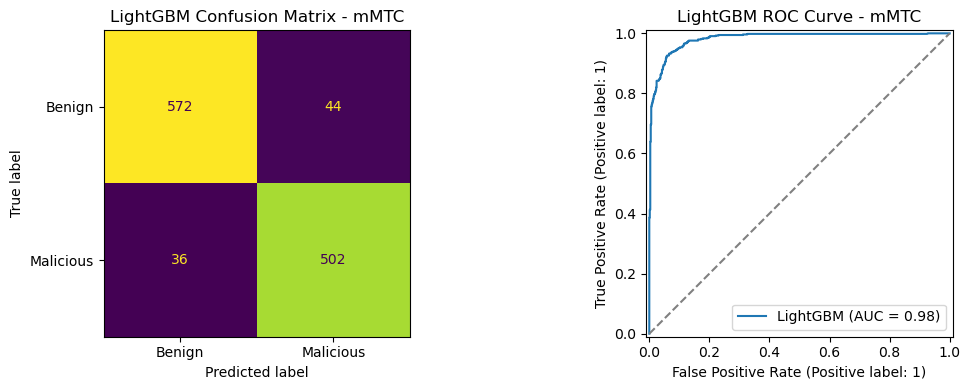


Dataset: URLLC
Model  : LightGBM
URLLC -> using 8 features, 4033 rows
No SMOTE applied (ratio=1.56:1)
Train Accuracy: 0.7721560846560847
Test  Accuracy: 0.7522299306243806
Accuracy : 0.7522
F1 macro : 0.7084
ROC-AUC  : 0.8360
              precision    recall  f1-score   support

      Benign       0.82      0.47      0.60       393
   Malicious       0.73      0.93      0.82       616

    accuracy                           0.75      1009
   macro avg       0.78      0.70      0.71      1009
weighted avg       0.77      0.75      0.73      1009



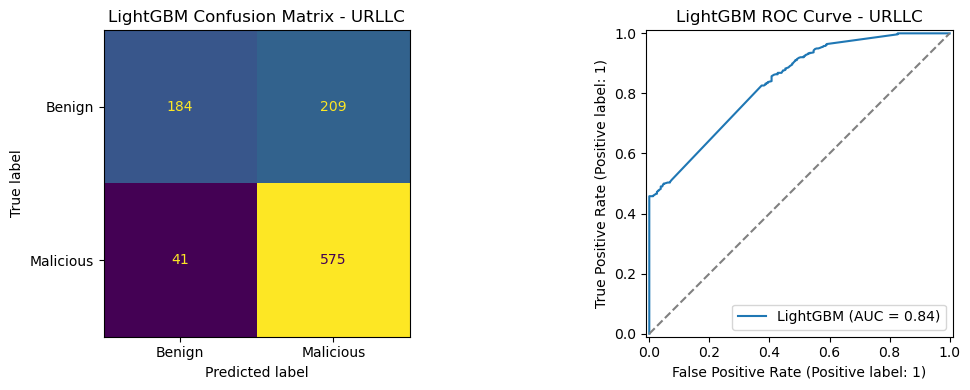


Dataset: eMBB
Model  : LightGBM
eMBB -> using 8 features, 5808 rows
No SMOTE applied (ratio=1.09:1)
Train Accuracy: 0.9995408631772268
Test  Accuracy: 0.9483471074380165
Accuracy : 0.9483
F1 macro : 0.9483
ROC-AUC  : 0.9926
              precision    recall  f1-score   support

      Benign       0.96      0.94      0.95       756
   Malicious       0.94      0.95      0.95       696

    accuracy                           0.95      1452
   macro avg       0.95      0.95      0.95      1452
weighted avg       0.95      0.95      0.95      1452



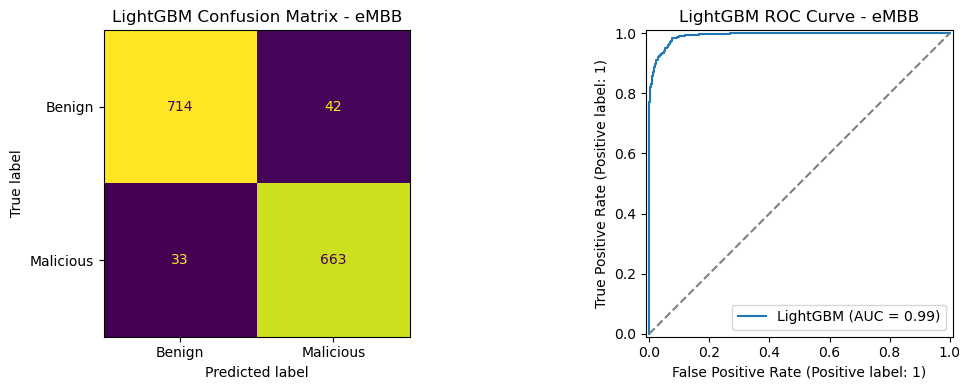


Dataset: TON_IoT
Model  : LightGBM
TON_IoT -> using 8 features, 210969 rows
No SMOTE applied (ratio=3.22:1)
Train Accuracy: 0.9975225310631628
Test  Accuracy: 0.9964545058111977
Accuracy : 0.9965
F1 macro : 0.9951
ROC-AUC  : 0.9998
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99     12496
   Malicious       1.00      1.00      1.00     40247

    accuracy                           1.00     52743
   macro avg       1.00      0.99      1.00     52743
weighted avg       1.00      1.00      1.00     52743



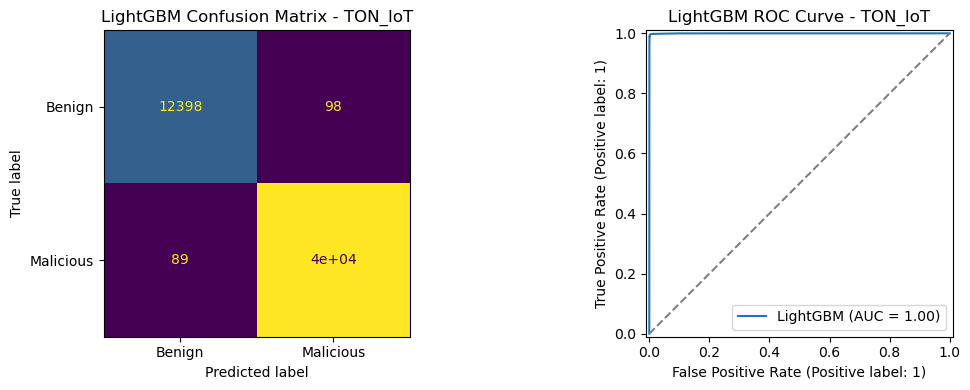

In [19]:
import lightgbm as lgb

results_lgbm = []

for name, df in datasets.items():
    print(f'\n==============================')
    print(f'Dataset: {name}')
    print(f'Model  : LightGBM')
    print(f'==============================')

    X, y = make_xy(df)
    keep = [c for c in FEATURE_MAP[name] if c in X.columns]
    X = X[keep]
    print(f'{name} -> using {len(keep)} features, {len(X)} rows')

    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
    )

    pre = build_preprocessor(X_train)
    X_train_proc = pre.fit_transform(X_train)
    X_test_proc  = pre.transform(X_test)

    counts = pd.Series(y_train).value_counts()
    ratio  = counts.max() / counts.min()
    if name != 'TON_IoT' and ratio > SMOTE_THRESHOLD:
        print(f'Applying SMOTE (ratio={ratio:.2f}:1)...')
        sm = SMOTE(sampling_strategy=0.5, random_state=42)
        X_train_proc, y_train = sm.fit_resample(X_train_proc, y_train)
        scale_pos = 1.0
    else:
        print(f'No SMOTE applied (ratio={ratio:.2f}:1)')
        scale_pos = ratio

    model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        min_child_samples=20,
        scale_pos_weight=scale_pos,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(
        X_train_proc, y_train,
        callbacks=[lgb.early_stopping(30, verbose=False),
                   lgb.log_evaluation(period=-1)],
        eval_set=[(X_test_proc, y_test)]
    )

    train_pred = model.predict(X_train_proc)
    test_pred  = model.predict(X_test_proc)
    print('Train Accuracy:', accuracy_score(y_train, train_pred))
    print('Test  Accuracy:', accuracy_score(y_test, test_pred))

    y_pred  = model.predict(X_test_proc)
    y_proba = model.predict_proba(X_test_proc)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, y_proba)
    print(f'Accuracy : {acc:.4f}')
    print(f'F1 macro : {f1:.4f}')
    print(f'ROC-AUC  : {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=le.classes_,
        ax=axes[0], colorbar=False
    )
    axes[0].set_title(f'LightGBM Confusion Matrix - {name}')
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name='LightGBM')
    axes[1].plot([0, 1], [0, 1], '--', color='gray')
    axes[1].set_title(f'LightGBM ROC Curve - {name}')
    plt.tight_layout()
    plt.show()

    results_lgbm.append({'Dataset': name, 'Model': 'LightGBM',
                         'Accuracy': acc, 'F1_macro': f1, 'ROC_AUC': auc})

## 📌 All Models Comparison Summary


## 🔍 Cell Description — All Models Comparison Summary

This cell **aggregates all results** from the three training loops into a single DataFrame and produces a comparative visualization.

**What it does:**

1. **Concatenates** `results_rf`, `results_xgb`, and `results_lr` (each a list of dicts with keys: `Dataset`, `Model`, `Accuracy`, `F1_macro`, `ROC_AUC`).

2. **Prints a sorted table** ordered by Dataset name and F1 macro descending — so for each dataset you can immediately see which model ranks best.

3. **Grouped bar chart:**
   - X-axis: 4 datasets
   - Y-axis: F1 macro score (0 to 1)
   - 3 colored bars per dataset group: blue = RandomForest, red = XGBoost, green = LogisticRegression
   - Width = 0.25 per bar, offset so bars don't overlap

4. **Average performance table:** Groups by model and averages all three metrics across all 4 datasets — the single most concise summary of which model wins overall.

**Why F1 macro is the primary metric here:** F1 macro averages F1 score across both classes equally regardless of class frequency. On imbalanced datasets, accuracy is misleading (a model that always predicts Benign can have 95% accuracy). F1 macro exposes poor performance on the minority (Malicious) class.


=== Full Results Summary ===
Dataset              Model  Accuracy  F1_macro  ROC_AUC
TON_IoT           LightGBM  0.996455  0.995096 0.999826
TON_IoT            XGBoost  0.995905  0.994358 0.999791
TON_IoT       RandomForest  0.994976  0.993075 0.999285
TON_IoT                MLP  0.993118  0.990522 0.999409
TON_IoT         ExtraTrees  0.966953  0.955807 0.995038
TON_IoT LogisticRegression  0.904177  0.881043 0.968573
  URLLC            XGBoost  0.752230  0.708974 0.836956
  URLLC           LightGBM  0.752230  0.708449 0.836035
  URLLC       RandomForest  0.668979  0.667600 0.837144
  URLLC         ExtraTrees  0.647175  0.642367 0.800093
  URLLC                MLP  0.714569  0.638438 0.695505
  URLLC LogisticRegression  0.536174  0.535973 0.645247
   eMBB           LightGBM  0.948347  0.948283 0.992590
   eMBB            XGBoost  0.946970  0.946888 0.990786
   eMBB       RandomForest  0.937328  0.937202 0.990847
   eMBB         ExtraTrees  0.889118  0.888772 0.973990
   eMBB           

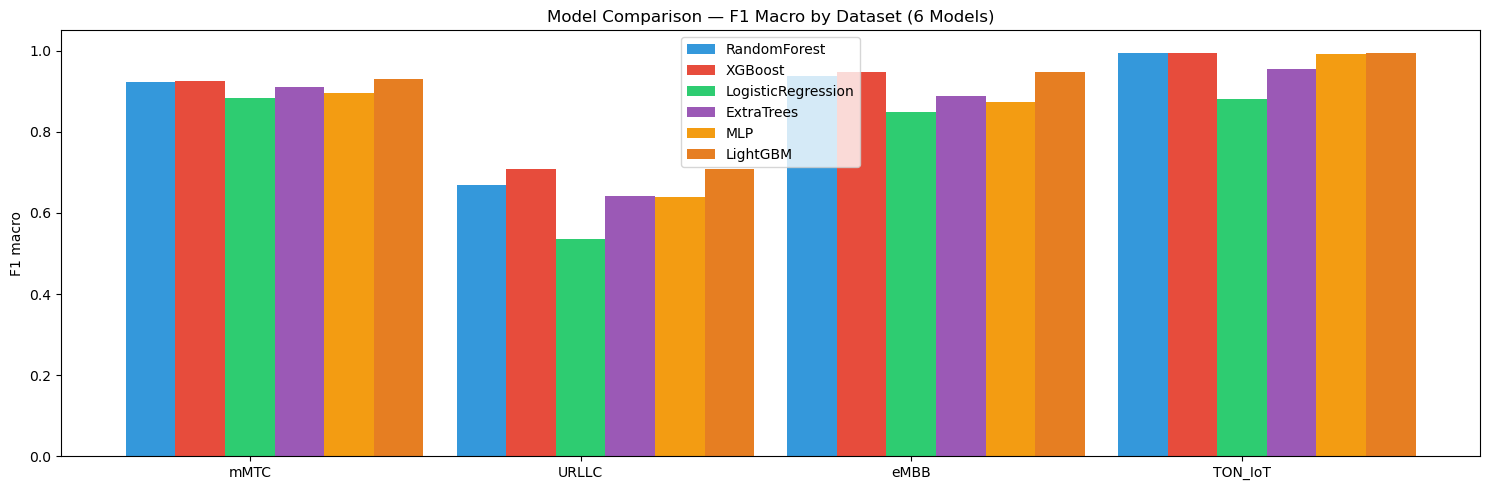


Average across all datasets:
                    Accuracy  F1_macro  ROC_AUC
Model                                          
ExtraTrees            0.8533    0.8491   0.9345
LightGBM              0.9069    0.8956   0.9526
LogisticRegression    0.7928    0.7869   0.8718
MLP                   0.8692    0.8494   0.9036
RandomForest          0.8813    0.8803   0.9517
XGBoost               0.9051    0.8938   0.9516


In [20]:
all_results = pd.DataFrame(results_rf + results_xgb + results_lr + results_et + results_mlp + results_lgbm)
pivot = all_results.pivot_table(index='Dataset', columns='Model',
                                values=['Accuracy','F1_macro','ROC_AUC'])
print('\n=== Full Results Summary ===')
print(all_results.sort_values(['Dataset','F1_macro'], ascending=[True,False]).to_string(index=False))

# Bar chart — F1 macro per model per dataset
fig, ax = plt.subplots(figsize=(15, 5))
datasets_list = all_results['Dataset'].unique()
models_list   = all_results['Model'].unique()
x = np.arange(len(datasets_list))
w = 0.15
colors = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#f39c12','#e67e22']
for i, (model, color) in enumerate(zip(models_list, colors)):
    vals = [all_results[(all_results.Dataset==d)&(all_results.Model==model)]['F1_macro'].values[0]
            if len(all_results[(all_results.Dataset==d)&(all_results.Model==model)]) > 0 else 0
            for d in datasets_list]
    ax.bar(x + i*w, vals, w, label=model, color=color)
ax.set_xticks(x + w*2)
ax.set_xticklabels(datasets_list)
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 macro')
ax.set_title('Model Comparison — F1 Macro by Dataset (6 Models)')
ax.legend()
plt.tight_layout()
plt.show()

# Average across datasets
print('\nAverage across all datasets:')
print(all_results.groupby('Model')[['Accuracy','F1_macro','ROC_AUC']].mean().round(4).to_string())


## 📌 Feature Importance
Validates that selected features are actually useful. Run after RF training loop.


## 🔍 Cell Description — Feature Importance Analysis

This cell **re-trains a Random Forest** on each dataset and extracts feature importance scores to validate that the selected features are genuinely informative.

**Why re-train instead of using the models from Cell 26?**
The RF models trained in Cell 26 are not stored (the loop variable `model` is overwritten each iteration). This cell explicitly saves models in `stored_models` and preprocessors in `stored_preprocessors` for reuse in feature importance extraction.

**Feature importance computation:**
- `rf.feature_importances_` returns a score per *transformed* column (after OneHotEncoding, categorical columns are split into multiple binary columns).
- For categorical features, the cell **groups OHE sub-columns back to their parent feature** using `get_parent()` — so instead of seeing `conn_state=SF`, `conn_state=REJ`, `conn_state=S0` as separate entries, you see a single `conn_state` bar with summed importance.
- **Color coding:** Features above the median importance → red; below → blue. This visually distinguishes the most impactful features.

**What to look for:**
- If `conn_state` or `proto` dominate in TON_IoT → categorical features are carrying predictive weight.
- If `TcpRtt` dominates in URLLC → latency is the most discriminating signal as expected.
- If any selected feature has near-zero importance across all datasets → it could be dropped without performance loss.

**Consistency check:** Hyperparameters match Cell 26 exactly (n_estimators=200, max_depth=15, min_samples_leaf=5) — SMOTE logic is also replicated with the same TON_IoT exclusion.

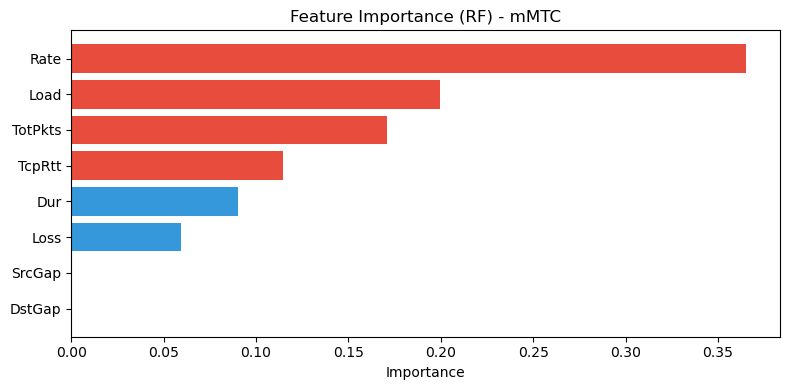

mMTC:  Parent  Importance
   Rate    0.365327
   Load    0.199586
TotPkts    0.171119
 TcpRtt    0.114733
    Dur    0.090034
   Loss    0.059201
 DstGap    0.000000
 SrcGap    0.000000


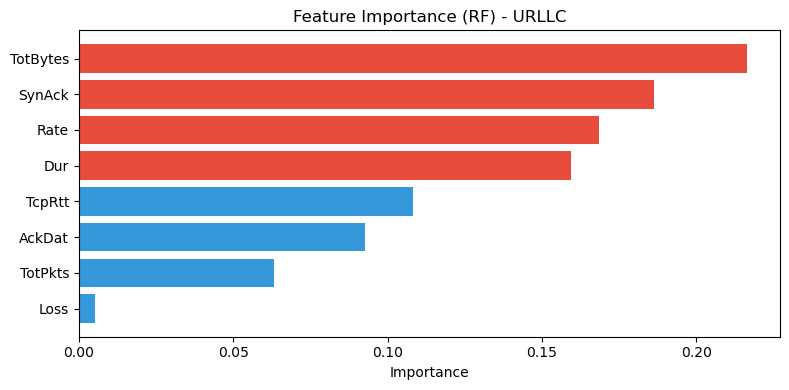

URLLC:   Parent  Importance
TotBytes    0.216283
  SynAck    0.186308
    Rate    0.168604
     Dur    0.159441
  TcpRtt    0.108190
  AckDat    0.092723
 TotPkts    0.063328
    Loss    0.005122


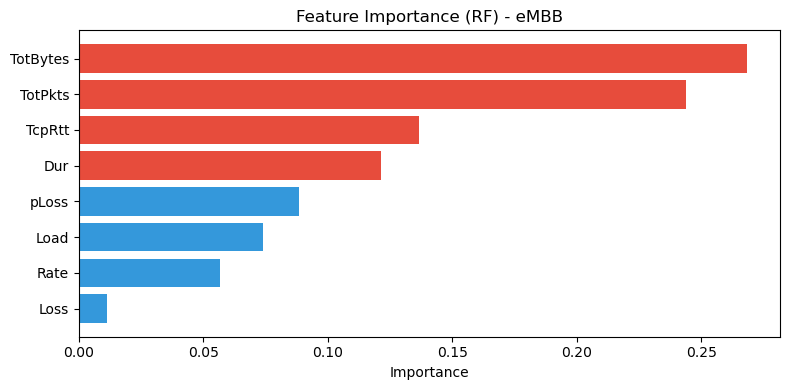

eMBB:   Parent  Importance
TotBytes    0.268219
 TotPkts    0.244035
  TcpRtt    0.136493
     Dur    0.121381
   pLoss    0.088265
    Load    0.073869
    Rate    0.056635
    Loss    0.011103


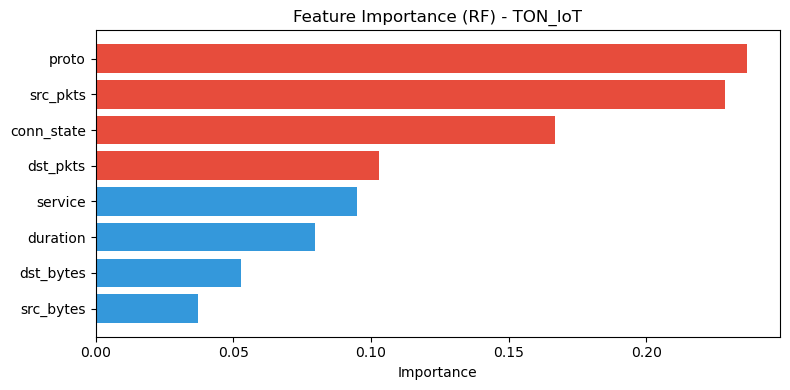

TON_IoT:     Parent  Importance
     proto    0.236746
  src_pkts    0.228514
conn_state    0.166691
  dst_pkts    0.103043
   service    0.094992
  duration    0.079734
 dst_bytes    0.052947
 src_bytes    0.037332


In [21]:
# Re-train RF on each dataset and store models for feature importance
stored_models = {}
stored_preprocessors = {}

for name, df in datasets.items():
    X, y = make_xy(df)
    keep = [c for c in FEATURE_MAP[name] if c in X.columns]
    X = X[keep]
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
    )
    pre = build_preprocessor(X_train)
    X_train_proc = pre.fit_transform(X_train)
    counts = pd.Series(y_train).value_counts()
    # ✅ Consistent with Cell 25 — skip SMOTE for TON_IoT
    if name != 'TON_IoT' and counts.max() / counts.min() > SMOTE_THRESHOLD:
        sm = SMOTE(sampling_strategy=0.5, random_state=42)
        X_train_proc, y_train = sm.fit_resample(X_train_proc, y_train)

    # ✅ Same hyperparameters as Cell 25
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=5,
        random_state=42, n_jobs=-1, class_weight='balanced'
    )
    rf.fit(X_train_proc, y_train)
    stored_models[name] = rf
    stored_preprocessors[name] = pre

# Plot feature importance per dataset
for name, rf in stored_models.items():
    pre  = stored_preprocessors[name]
    X, _ = make_xy(datasets[name])
    keep = [c for c in FEATURE_MAP[name] if c in X.columns]
    X = X[keep]
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
    ohe_names = []
    if cat_cols and 'cat' in pre.named_transformers_:
        ohe = pre.named_transformers_['cat']['encoder']
        for i, cat in enumerate(cat_cols):
            ohe_names += [f'{cat}={v}' for v in ohe.categories_[i]]
    all_names = num_cols + ohe_names
    imp = rf.feature_importances_
    min_len = min(len(imp), len(all_names))
    imp_df = pd.DataFrame({'Feature': all_names[:min_len], 'Importance': imp[:min_len]})

    def get_parent(nm):
        for cat in cat_cols:
            if nm.startswith(cat + '='):
                return cat
        return nm
    imp_df['Parent'] = imp_df['Feature'].apply(get_parent)
    grp = imp_df.groupby('Parent')['Importance'].sum().reset_index()
    grp = grp.sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(8, 4))
    colors = ['#e74c3c' if v > grp.Importance.median() else '#3498db'
              for v in grp.Importance]
    ax.barh(grp.Parent, grp.Importance, color=colors)
    ax.set_title(f'Feature Importance (RF) - {name}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    print(f'{name}:', grp.sort_values('Importance', ascending=False).to_string(index=False))

## 📌 Final Decision Output
### Final Output: Attack Detection & Classification
Three-stage pipeline: binary detection → confidence filtering → attack type classification.
- **Stage 1** — Random Forest binary detection
- **Stage 2** — Confidence gate (threshold = 0.55)
- **Stage 3** — Rule-based attack subtype identification


## 🔍 Cell Description — Final Decision Pipeline (Attack Detection & Classification)

This is the **final production-style inference pipeline**. It implements a three-stage decision system that goes beyond binary classification to produce named attack type labels.

---

### Stage 1 — Binary Detection (Random Forest)
Re-trains a Random Forest (300 trees for slightly more stability) on each dataset and computes per-sample probabilities (`proba`) and binary predictions (`pred = 0 or 1`).

---

### Stage 2 — Confidence Gate
Instead of directly trusting the binary prediction, a `FINAL_THRESHOLD = 0.30` is applied:
- `binary == 0` → predicted **Benign** (RF says no attack, take it at face value)
- `binary == 1` AND `proba < 0.30` → labeled **False Alarm** (RF suspects attack but with < 30% confidence — too uncertain to act on)
- `binary == 1` AND `proba ≥ 0.30` → passes to Stage 3

This threshold is deliberately low (0.30) to minimize false negatives (missed real attacks) — in a security context, missing an attack is worse than raising a false alarm.

---

### Stage 3 — Rule-Based Attack Subtype Classification (`classify_attack_type`)
For samples that pass the confidence gate, this function applies hand-crafted decision rules per dataset to name the specific attack type:

**eMBB rules:**
- Short duration + near-zero SynAck + few packets → `TCP SYN Flood`
- Packet loss % > 4% → `Bandwidth Saturation`

**mMTC rules:**
- < 10 packets + duration < 1s → `TCP SYN Scan / Connection Flooding`
- Duration > 3s + load < 3000 → `Slow-Rate Resource Exhaustion`
- Otherwise → `FIN Scan`

**URLLC rules:**
- Duration = 0 and single packet → `UDP DDoS Flood`
- High RTT + few packets → `RST Injection`
- RTT > 100ms → `SLA Violation / DoS`
- Otherwise → `Reconnaissance`

**TON_IoT rules (9 attack types):**
- src_pkts > 1000 in < 2s → `DDoS`
- src_pkts > 200 in < 5s → `DoS`
- Rejected/reset connections with few packets → `Scanning`
- SSH/FTP service with few packets → `Password` (brute force)
- Long duration + low bytes + complete connection → `Backdoor`
- High src_bytes + long duration → `Ransomware`
- HTTP service: large response = `Injection`; otherwise `XSS`
- Non-standard protocol or tiny complete connection → `MITM`

---

### Evaluation
The final output uses `classification_report` on the expanded label set (Benign, False Alarm, + all attack subtypes per dataset) — providing precision, recall, and F1 per named attack type rather than just binary accuracy.

In [22]:
import lightgbm as lgb
import pickle, os

FINAL_THRESHOLD = 0.30

def classify_attack_type(name, row):
    def g(col, default=None):
        return row.get(col, default)

    # ── eMBB ─────────────────────────────────────────────────────────────
    if name == "eMBB":
        dur    = g("Dur",     1.0)
        rate   = g("Rate",    0.0)
        totpkt = g("TotPkts", 50)
        # TCP SYN Flood: short-lived burst at high packet rate, few packets
        # Data shows: SYN Flood flows have Dur <= 0.35s AND Rate > 50 pkt/s
        if dur <= 0.35 and rate > 50:
            return "TCP SYN Flood"
        # Bandwidth Saturation: sustained flow, lower rate, more packets, high load
        return "Bandwidth Saturation"

    # ── mMTC ─────────────────────────────────────────────────────────────
    if name == "mMTC":
        dur    = g("Dur", 1.0)
        tot_pk = g("TotPkts", 100)
        load   = g("Load", 5000)
        if tot_pk < 10 and dur < 1.0:
            return "TCP SYN Scan / Connection Flooding"
        if dur > 3.0 and load < 3000:
            return "Slow-Rate Resource Exhaustion"
        return "FIN Scan"

    # ── URLLC ────────────────────────────────────────────────────────────
    if name == "URLLC":
        dur    = g("Dur", 1.0)
        tot_pk = g("TotPkts", 10)
        rtt    = g("TcpRtt", 0.01)
        if dur == 0 and tot_pk == 1:
            return "UDP DDoS Flood"
        if rtt > 0.05 and tot_pk < 5:
            return "RST Injection"
        if rtt > 0.1:
            return "SLA Violation / DoS"
        return "Reconnaissance"

    # ── TON_IoT (9 attack types) ──────────────────────────────────────────
    if name == "TON_IoT":
        src_pkts   = g("src_pkts",   10)
        dst_pkts   = g("dst_pkts",   10)
        src_bytes  = g("src_bytes",  1000)
        dst_bytes  = g("dst_bytes",  1000)
        duration   = g("duration",   1.0)
        conn_state = g("conn_state", "SF")
        service    = g("service",    "-")
        proto      = g("proto",      "tcp")
        if src_pkts > 1000 and duration < 2.0:
            return "DDoS"
        if src_pkts > 200 and duration < 5.0:
            return "DoS"
        if conn_state in ("REJ","RSTO","RSTOS0") and src_pkts < 10:
            return "Scanning"
        if service in ("ssh","ftp","ftp-data") and src_pkts < 20:
            return "Password"
        if duration > 60 and src_bytes < 5000 and conn_state == "SF":
            return "Backdoor"
        if src_bytes > 100000 and duration > 10:
            return "Ransomware"
        if service in ("http","http-alt"):
            if dst_bytes > src_bytes * 2:
                return "Injection"
            return "XSS"
        if proto not in ("tcp","udp") or (conn_state == "SF" and src_bytes < 500):
            return "MITM"
        return "DoS"

    return "Unknown"



# ── Run final pipeline: LightGBM only ────────────────────────────────────────
lgbm_models        = {}
lgbm_preprocessors = {}
lgbm_label_encoders = {}
lgbm_features      = {}

for name, df in datasets.items():
    print(f"==============================")
    print(f"FINAL DECISION DATASET: {name}")
    print(f"Model: LightGBM")
    print(f"==============================")

    X, y = make_xy(df)
    keep = [c for c in FEATURE_MAP[name] if c in X.columns]
    X = X[keep]
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
    )
    pre = build_preprocessor(X_train)
    X_train_proc = pre.fit_transform(X_train)
    X_test_proc  = pre.transform(X_test)

    counts = pd.Series(y_train).value_counts()
    ratio  = counts.max() / counts.min()
    if name != "TON_IoT" and ratio > SMOTE_THRESHOLD:
        print(f"  Applying SMOTE (ratio={ratio:.2f}:1)...")
        sm = SMOTE(sampling_strategy=0.5, random_state=42)
        X_train_proc, y_train = sm.fit_resample(X_train_proc, y_train)
        spw = 1.0
    else:
        print(f"  No SMOTE (ratio={ratio:.2f}:1)")
        spw = ratio

    # ── Train LightGBM ────────────────────────────────────────────────────
    lgbm_f = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        min_child_samples=20,
        scale_pos_weight=spw,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    lgbm_f.fit(
        X_train_proc, y_train,
        callbacks=[lgb.early_stopping(30, verbose=False),
                   lgb.log_evaluation(period=-1)],
        eval_set=[(X_test_proc, y_test)]
    )
    print(f"  LightGBM trained on {X_train_proc.shape[0]} samples.")

    # ── Save for Streamlit ────────────────────────────────────────────────
    lgbm_models[name]         = lgbm_f
    lgbm_preprocessors[name]  = pre
    lgbm_label_encoders[name] = le
    lgbm_features[name]       = keep

    # ── Predict with confidence gate ──────────────────────────────────────
    proba  = lgbm_f.predict_proba(X_test_proc)[:, 1]
    pred   = (proba >= 0.5).astype(int)

    X_test_df  = X_test.reset_index(drop=True)
    y_test_arr = pd.Series(y_test).reset_index(drop=True)

    results_decision = []
    true_labels      = []

    for i in range(len(X_test_df)):
        row    = X_test_df.iloc[i].to_dict()
        t      = y_test_arr.iloc[i]
        p      = proba[i]
        binary = pred[i]

        if binary == 0:
            pred_label = "Benign"
        elif p < FINAL_THRESHOLD:
            pred_label = "False Alarm"
        else:
            pred_label = classify_attack_type(name, row)
        results_decision.append(pred_label)

        if t == 0:
            true_label = "Benign"
        else:
            true_label = classify_attack_type(name, row)
        true_labels.append(true_label)

    from sklearn.metrics import classification_report as cr
    unique_labels = sorted(set(results_decision + true_labels))
    print(cr(true_labels, results_decision, labels=unique_labels, zero_division=0))

# ── Export LightGBM models for Streamlit ─────────────────────────────────────
os.makedirs("streamlit_app/models", exist_ok=True)
with open("streamlit_app/models/lgbm_models.pkl",         "wb") as f: pickle.dump(lgbm_models, f)
with open("streamlit_app/models/lgbm_preprocessors.pkl",  "wb") as f: pickle.dump(lgbm_preprocessors, f)
with open("streamlit_app/models/lgbm_features.pkl",       "wb") as f: pickle.dump(lgbm_features, f)
with open("streamlit_app/models/lgbm_label_encoders.pkl", "wb") as f: pickle.dump(lgbm_label_encoders, f)
print("LightGBM models exported to streamlit_app/models/ — ready for Streamlit app.")


FINAL DECISION DATASET: mMTC
Model: LightGBM
  No SMOTE (ratio=1.14:1)
  LightGBM trained on 3461 samples.
                                    precision    recall  f1-score   support

                            Benign       0.94      0.93      0.93       616
                          FIN Scan       0.90      0.92      0.91       320
     Slow-Rate Resource Exhaustion       0.97      0.98      0.98       199
TCP SYN Scan / Connection Flooding       0.67      0.53      0.59        19

                          accuracy                           0.93      1154
                         macro avg       0.87      0.84      0.85      1154
                      weighted avg       0.93      0.93      0.93      1154

FINAL DECISION DATASET: URLLC
Model: LightGBM
  No SMOTE (ratio=1.56:1)
  LightGBM trained on 3024 samples.
                precision    recall  f1-score   support

        Benign       0.75      0.54      0.63       393
 RST Injection       0.67      1.00      0.80         2
Recon